# 📊 Benchmarking de Indicadores Financeiros — B3 (2010–2024)

> **Fonte:** CVM / B3 — Empresas de capital aberto em fase operacional
> **Escopo:** Indicadores calculados sobre `layer_03_gold.mart_indicadores_financeiros`
> **Metodologia:** Análise setorial com mediana como estatística central (robusta a outliers)

---


## ⚙️ Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from dotenv import load_dotenv
from IPython.display import display

warnings.filterwarnings('ignore')
load_dotenv()

# ── Tema visual (estilo consultoria) ─────────────────────────────────────────
sns.set_theme(
    style='whitegrid',
    palette='muted',
    font_scale=1.12,
    rc={
        'figure.dpi': 130,
        'figure.facecolor': 'white',
        'axes.facecolor': '#F8F9FA',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titlesize': 13,
        'axes.titleweight': 'bold',
        'axes.labelsize': 11,
        'legend.fontsize': 10,
    }
)

C_BLUE   = '#2563EB'
C_RED    = '#DC2626'
C_GREEN  = '#16A34A'
C_ORANGE = '#D97706'
C_GRAY   = '#6B7280'
C_PURPLE = '#7C3AED'

def add_subtitle(ax, text):
    ax.set_title(ax.get_title() + f'\n', pad=4)
    ax.annotate(text, xy=(0, 1.01), xycoords='axes fraction',
                fontsize=9, color=C_GRAY, ha='left')

def fmt_pct(x, _):  return f'{x:.0%}'
def fmt_1f(x, _):   return f'{x:.1f}'

def clip_viz(s, lo=0.02, hi=0.98):
    """Clip série nos percentis lo/hi para remover outliers visuais."""
    return s.clip(s.quantile(lo), s.quantile(hi))

print('✅ Setup concluído.')


✅ Setup concluído.


In [2]:
def create_engine_():
    from urllib.parse import quote_plus
    u = quote_plus(os.getenv('DB_USER', 'postgres'))
    p = quote_plus(os.getenv('DB_PASS', 'password'))
    h = os.getenv('DB_HOST', 'localhost')
    port = os.getenv('DB_PORT', '5432')
    db = os.getenv('DB_NAME', 'data_lake')
    return create_engine(f'postgresql+psycopg2://{u}:{p}@{h}:{port}/{db}')

engine = create_engine_()

Q = 'SELECT * FROM layer_03_gold.mart_indicadores_financeiros'
with engine.connect() as conn:
    df_raw = pd.read_sql(text(Q), conn)

print(f'✅ Mart carregado: {len(df_raw):,} linhas × {df_raw.shape[1]} colunas')


✅ Mart carregado: 2,321 linhas × 66 colunas


In [3]:
df = df_raw.copy()
df['ANO'] = pd.to_datetime(df['DT_REFER']).dt.year

# Filtrar período útil (2025 ainda incompleto)
df = df[df['ANO'].between(2010, 2024)].copy()

# Setor: label curto + fallback
df['SETOR_LABEL'] = df['SETOR'].str[:38].fillna('Não Classificado')

# Top 10 setores por número de observações
TOP10 = df['SETOR_LABEL'].value_counts().head(10).index.tolist()
df_top = df[df['SETOR_LABEL'].isin(TOP10)].copy()

# Indicadores disponíveis
IND_COLS = [c for c in df.columns if c.startswith('IND_')]

print(f'🏢 Empresas:       {df["CNPJ_CIA"].nunique()}')
print(f'📅 Período:        {df["ANO"].min()} – {df["ANO"].max()}  ({df["ANO"].nunique()} anos)')
print(f'🏭 Setores únicos: {df["SETOR_LABEL"].nunique()}')
print(f'📊 Indicadores:    {len(IND_COLS)}')
print(f'📈 Top 10 setores representam {len(df_top)/len(df)*100:.0f}% das observações')


🏢 Empresas:       202
📅 Período:        2010 – 2024  (15 anos)
🏭 Setores únicos: 24
📊 Indicadores:    30
📈 Top 10 setores representam 77% das observações


---
## 1 · Panorama do Dataset

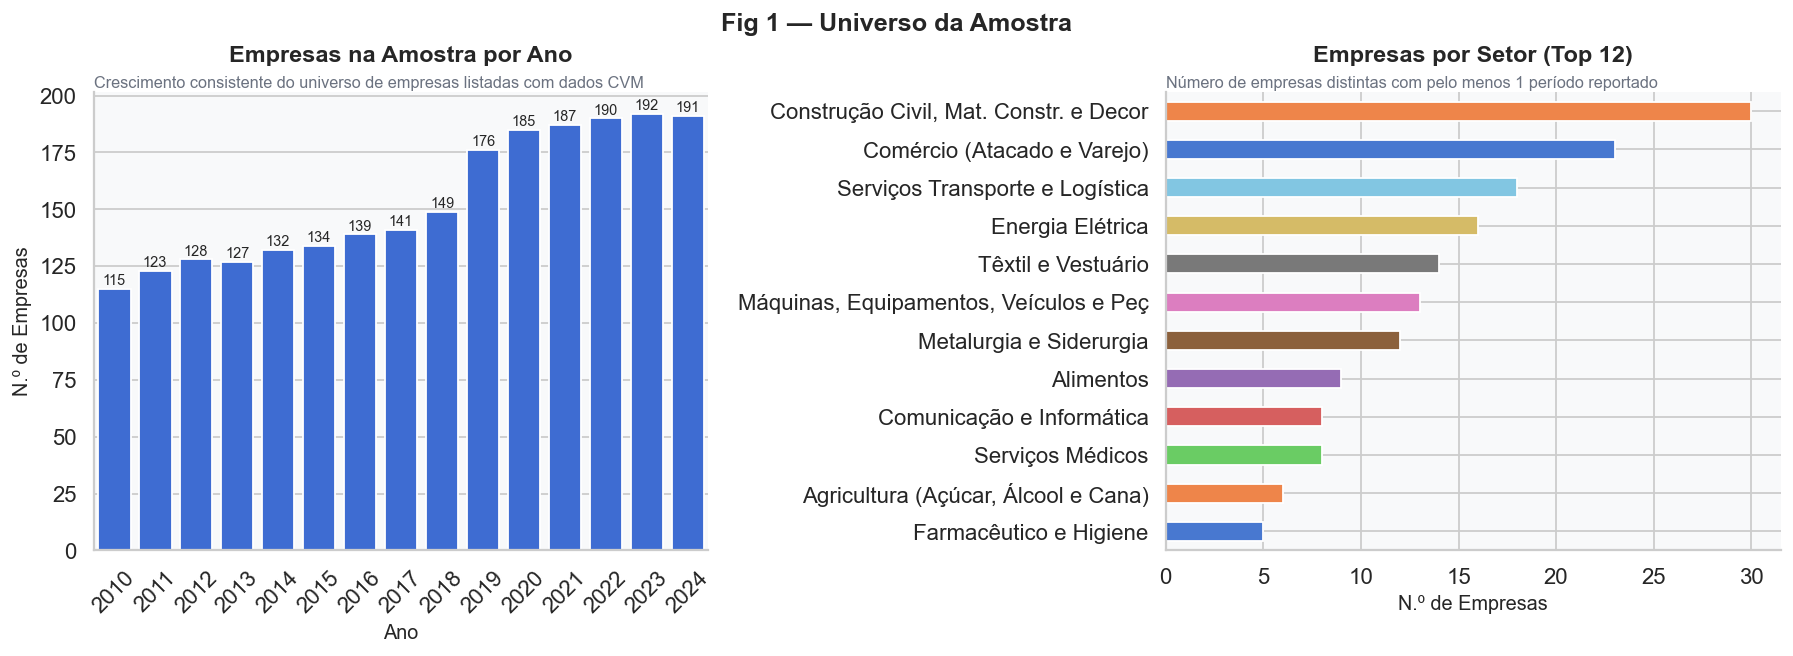

In [4]:
# ── 1a. Evolução do universo de empresas ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Empresas por ano
emp_ano = df.groupby('ANO')['CNPJ_CIA'].nunique().reset_index(name='N_EMPRESAS')
sns.barplot(data=emp_ano, x='ANO', y='N_EMPRESAS', color=C_BLUE, ax=axes[0])
axes[0].set_title('Empresas na Amostra por Ano')
add_subtitle(axes[0], 'Crescimento consistente do universo de empresas listadas com dados CVM')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('N.º de Empresas')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, emp_ano['N_EMPRESAS']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=8)

# Composição setorial (top 12)
setor_count = df.groupby('SETOR_LABEL')['CNPJ_CIA'].nunique().sort_values(ascending=True).tail(12)
colors = sns.color_palette('muted', len(setor_count))
setor_count.plot(kind='barh', color=colors, ax=axes[1])
axes[1].set_title('Empresas por Setor (Top 12)')
add_subtitle(axes[1], 'Número de empresas distintas com pelo menos 1 período reportado')
axes[1].set_xlabel('N.º de Empresas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.suptitle('Fig 1 — Universo da Amostra', y=1.01, fontsize=14, fontweight='bold')
plt.show()


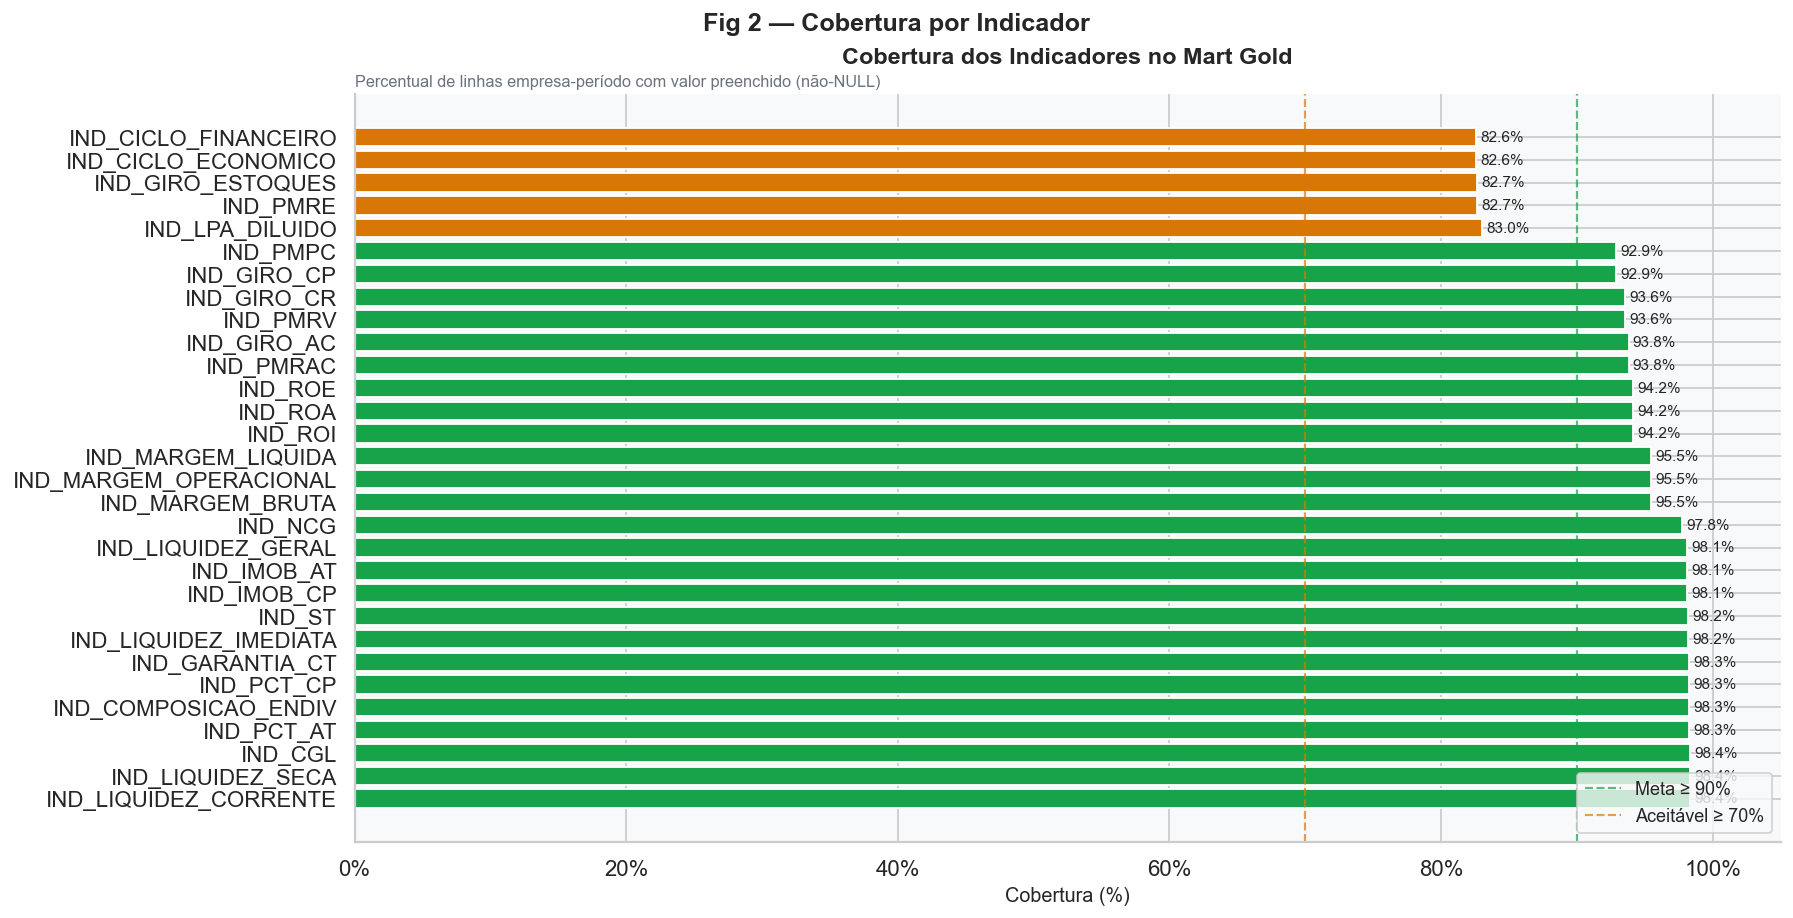

In [5]:
# ── 1b. Cobertura dos indicadores ────────────────────────────────────────────
cobertura = (df[IND_COLS].notna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors_bar = [C_GREEN if v >= 90 else (C_ORANGE if v >= 70 else C_RED) for v in cobertura]
bars = ax.barh(cobertura.index, cobertura.values, color=colors_bar)

ax.axvline(90, color=C_GREEN,  linestyle='--', lw=1.2, alpha=0.7, label='Meta ≥ 90%')
ax.axvline(70, color=C_ORANGE, linestyle='--', lw=1.2, alpha=0.7, label='Aceitável ≥ 70%')
ax.set_xlim(0, 105)
ax.set_xlabel('Cobertura (%)')
ax.set_title('Cobertura dos Indicadores no Mart Gold')
add_subtitle(ax, 'Percentual de linhas empresa-período com valor preenchido (não-NULL)')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for bar, val in zip(bars, cobertura.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5)

plt.tight_layout()
plt.suptitle('Fig 2 — Cobertura por Indicador', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 2 · Liquidez

> **Referência:** Liquidez Corrente satisfatória acima de **1,5×**; Geral acima de **1,0×**.
> Fontes: `IND_LIQUIDEZ_GERAL`, `IND_LIQUIDEZ_CORRENTE`, `IND_LIQUIDEZ_SECA`, `IND_LIQUIDEZ_IMEDIATA`


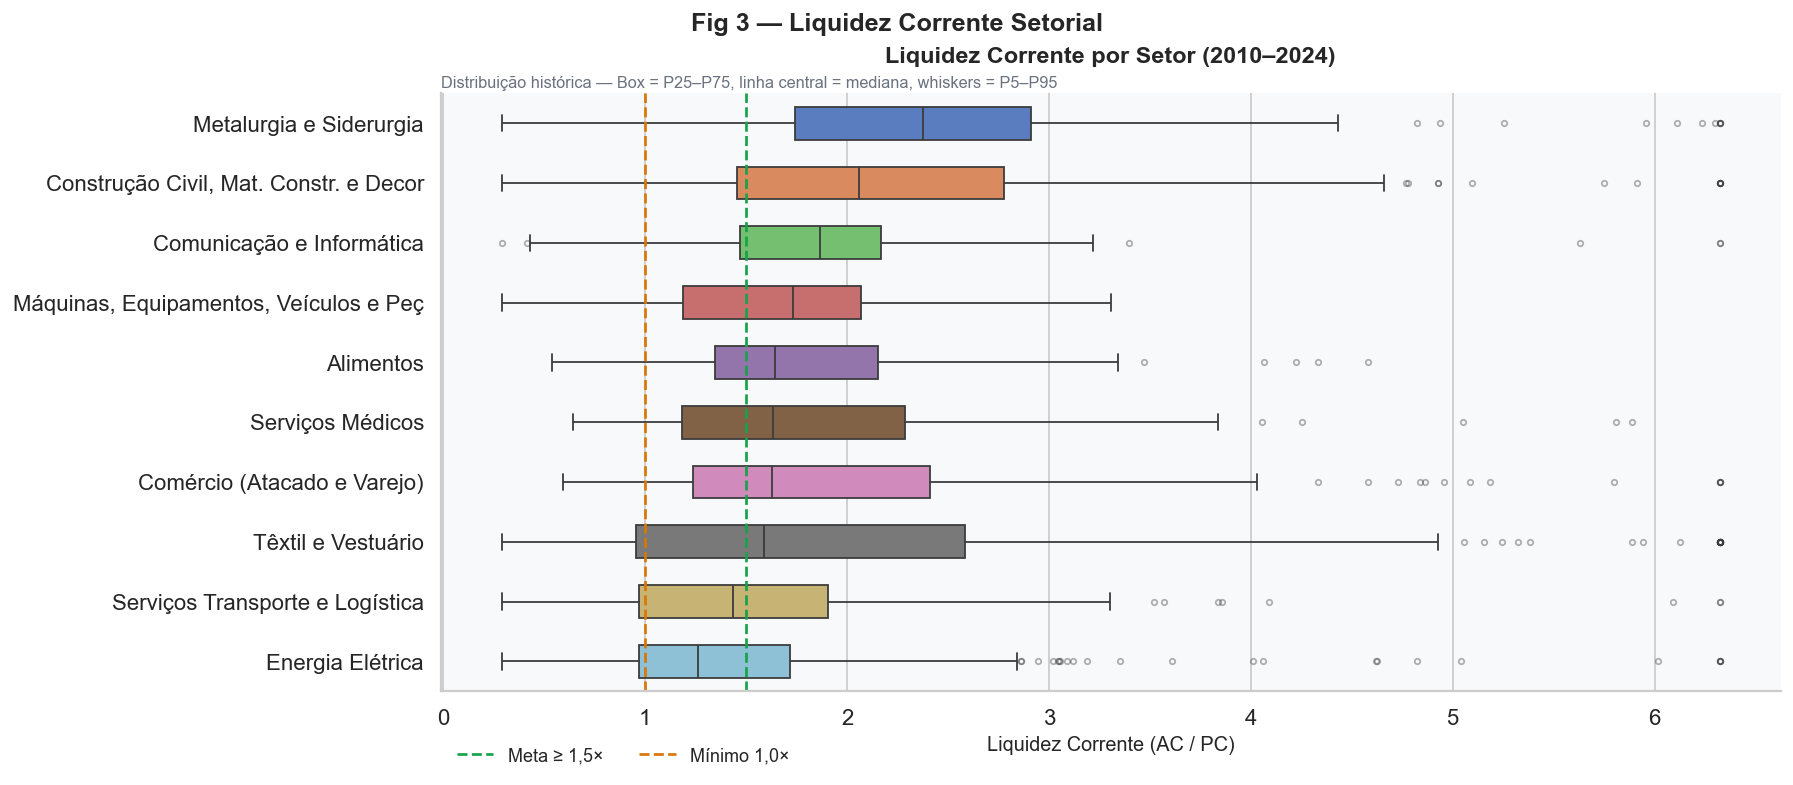

In [6]:
# ── 2a. Distribuição da Liquidez Corrente por Setor ──────────────────────────
liq_data = df_top.copy()
liq_data['IND_LIQUIDEZ_CORRENTE_VIZ'] = clip_viz(liq_data['IND_LIQUIDEZ_CORRENTE'])

order = (liq_data.groupby('SETOR_LABEL')['IND_LIQUIDEZ_CORRENTE']
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=liq_data, y='SETOR_LABEL', x='IND_LIQUIDEZ_CORRENTE_VIZ',
    order=order, palette='muted', width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)
ax.axvline(1.5, color=C_GREEN,  linestyle='--', lw=1.5, label='Meta ≥ 1,5×')
ax.axvline(1.0, color=C_ORANGE, linestyle='--', lw=1.5, label='Mínimo 1,0×')
ax.set_title('Liquidez Corrente por Setor (2010–2024)')
add_subtitle(ax, 'Distribuição histórica — Box = P25–P75, linha central = mediana, whiskers = P5–P95')
ax.set_xlabel('Liquidez Corrente (AC / PC)')
ax.set_ylabel('')
ax.legend(
    ncol=2,
    loc='lower left', bbox_to_anchor=(0.0, -0.15),
    frameon=False, framealpha=0.9, edgecolor='#E5E7EB'
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.suptitle('Fig 3 — Liquidez Corrente Setorial', y=1.01, fontsize=14, fontweight='bold')
plt.show()


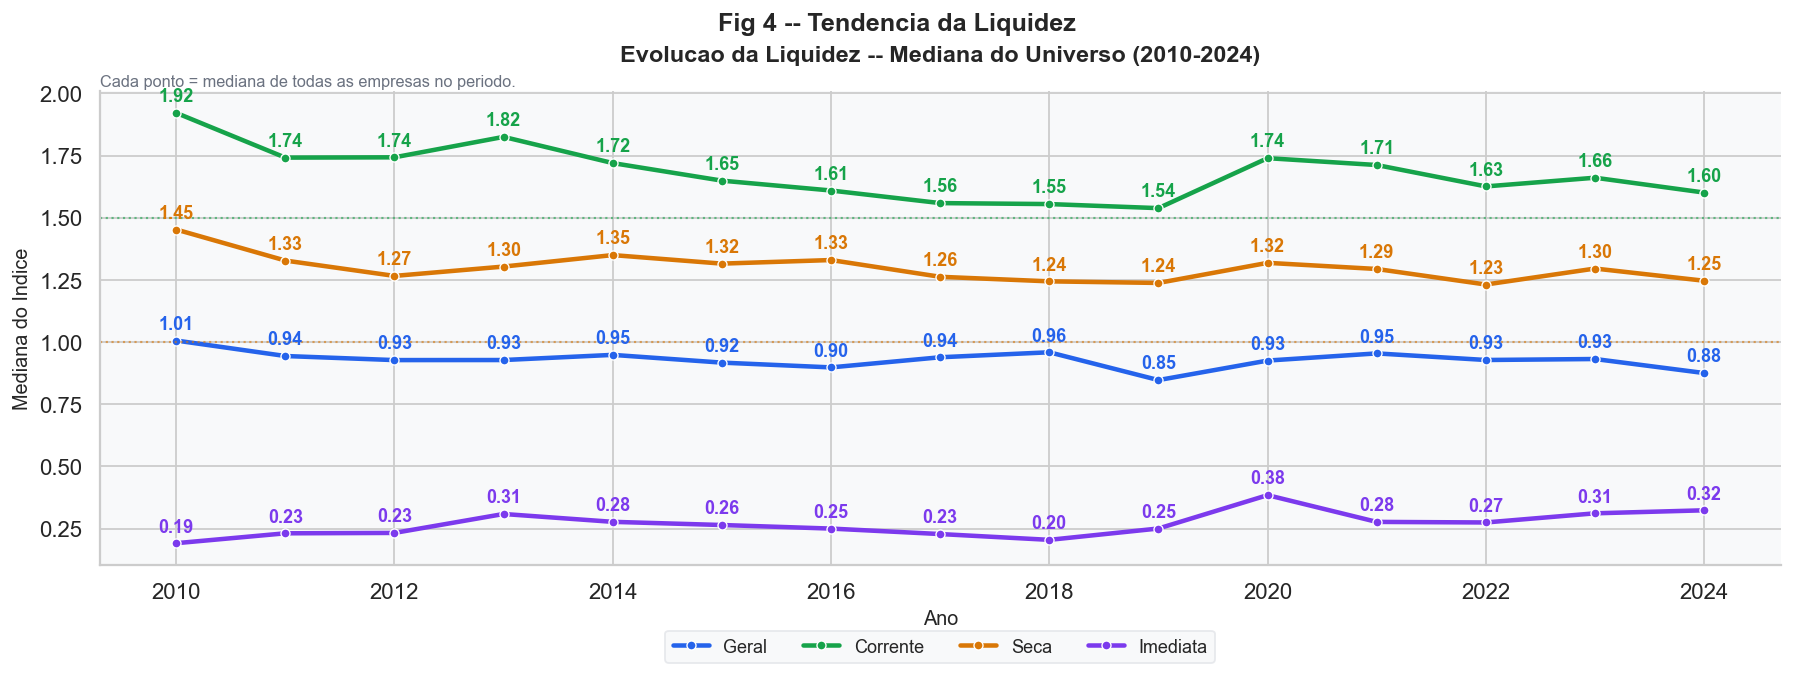

In [7]:
# ── 2b. Evolucao temporal -- 4 indices de liquidez ───────────────────────────
liq_ts = df.groupby('ANO')[
    ['IND_LIQUIDEZ_GERAL','IND_LIQUIDEZ_CORRENTE','IND_LIQUIDEZ_SECA','IND_LIQUIDEZ_IMEDIATA']
].median().reset_index()

liq_melt = liq_ts.melt(id_vars='ANO', var_name='Indicador', value_name='Mediana')
liq_melt['Indicador'] = liq_melt['Indicador'].str.replace('IND_LIQUIDEZ_','').str.title()

fig, ax = plt.subplots(figsize=(14, 5))
palette = [C_BLUE, C_GREEN, C_ORANGE, C_PURPLE]
sns.lineplot(data=liq_melt, x='ANO', y='Mediana', hue='Indicador',
             palette=palette, linewidth=2.5, marker='o', markersize=5, ax=ax)

# ── Rotulos acima de cada marcador ────────────────────────────────────────────
indicadores = ['IND_LIQUIDEZ_GERAL','IND_LIQUIDEZ_CORRENTE','IND_LIQUIDEZ_SECA','IND_LIQUIDEZ_IMEDIATA']
for col, cor in zip(indicadores, palette):
    for _, row in liq_ts[['ANO', col]].dropna().iterrows():
        ax.text(row['ANO'], row[col] + 0.03, f'{row[col]:.2f}',
                ha='center', va='bottom', fontsize=10, color=cor, fontweight='bold')

ax.axhline(1.5, color=C_GREEN,  linestyle=':', lw=1.2, alpha=0.6)
ax.axhline(1.0, color=C_ORANGE, linestyle=':', lw=1.2, alpha=0.6)
ax.set_title('Evolucao da Liquidez -- Mediana do Universo (2010-2024)')
add_subtitle(ax, 'Cada ponto = mediana de todas as empresas no periodo.')
ax.set_xlabel('Ano')
ax.set_ylabel('Mediana do Indice')
ax.legend(
    title='', ncol=4,
    loc='upper center', bbox_to_anchor=(0.5, -0.12),
    frameon=True, framealpha=0.9, edgecolor='#E5E7EB'
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.suptitle('Fig 4 -- Tendencia da Liquidez', y=1.01, fontsize=14, fontweight='bold')
plt.show()


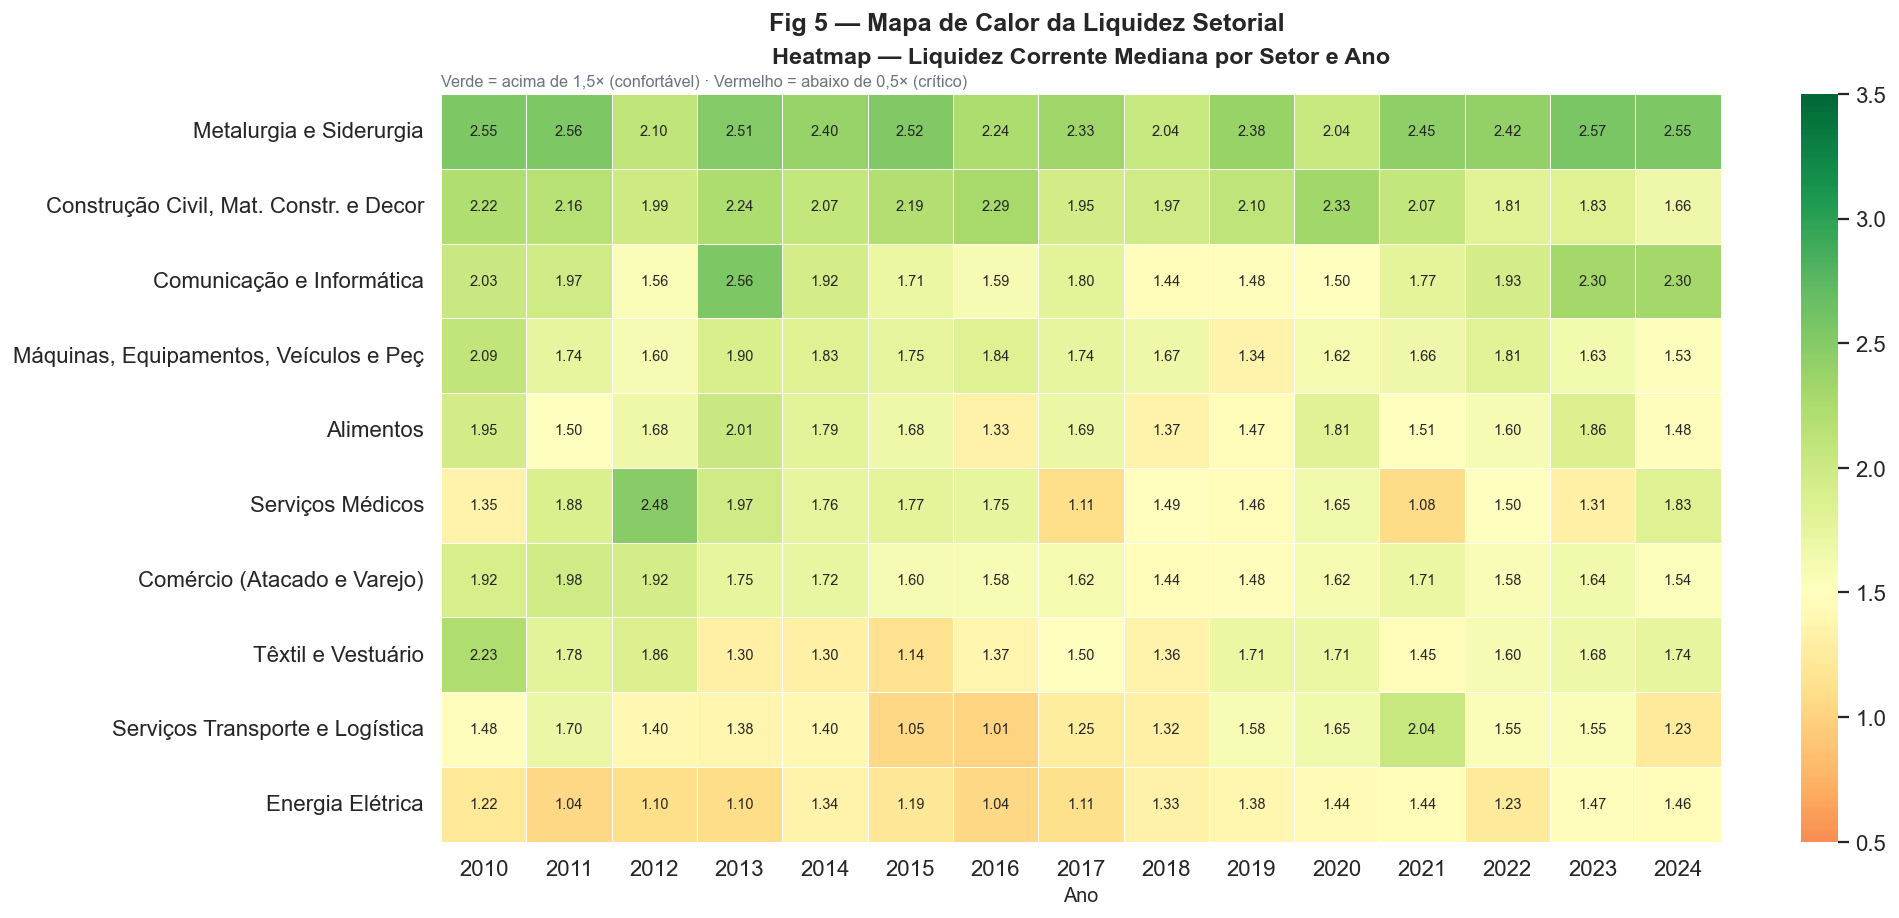

In [8]:
# ── 2c. Heatmap: Liquidez Corrente mediana por Setor × Ano ───────────────────
pivot_liq = df_top.pivot_table(
    values='IND_LIQUIDEZ_CORRENTE', index='SETOR_LABEL', columns='ANO', aggfunc='median'
)
pivot_liq = pivot_liq.reindex(
    pivot_liq.median(axis=1).sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot_liq, annot=True, fmt='.2f', cmap='RdYlGn',
    center=1.5, vmin=0.5, vmax=3.5,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Heatmap — Liquidez Corrente Mediana por Setor e Ano')
add_subtitle(ax, 'Verde = acima de 1,5× (confortável) · Vermelho = abaixo de 0,5× (crítico)')
ax.set_xlabel('Ano')
ax.set_ylabel('')
plt.tight_layout()
plt.suptitle('Fig 5 — Mapa de Calor da Liquidez Setorial', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 3 · Endividamento e Estrutura de Capital

> `IND_PCT_AT` = Capital de terceiros / Ativo Total — quanto do ativo é financiado por dívida
> `IND_COMPOSICAO_ENDIV` = Passivo Circulante / (PC + ELP) — concentração de dívida no curto prazo
> `AUX_DIVIDA_LIQUIDA` = Dívida Bruta − Caixa (DFC)


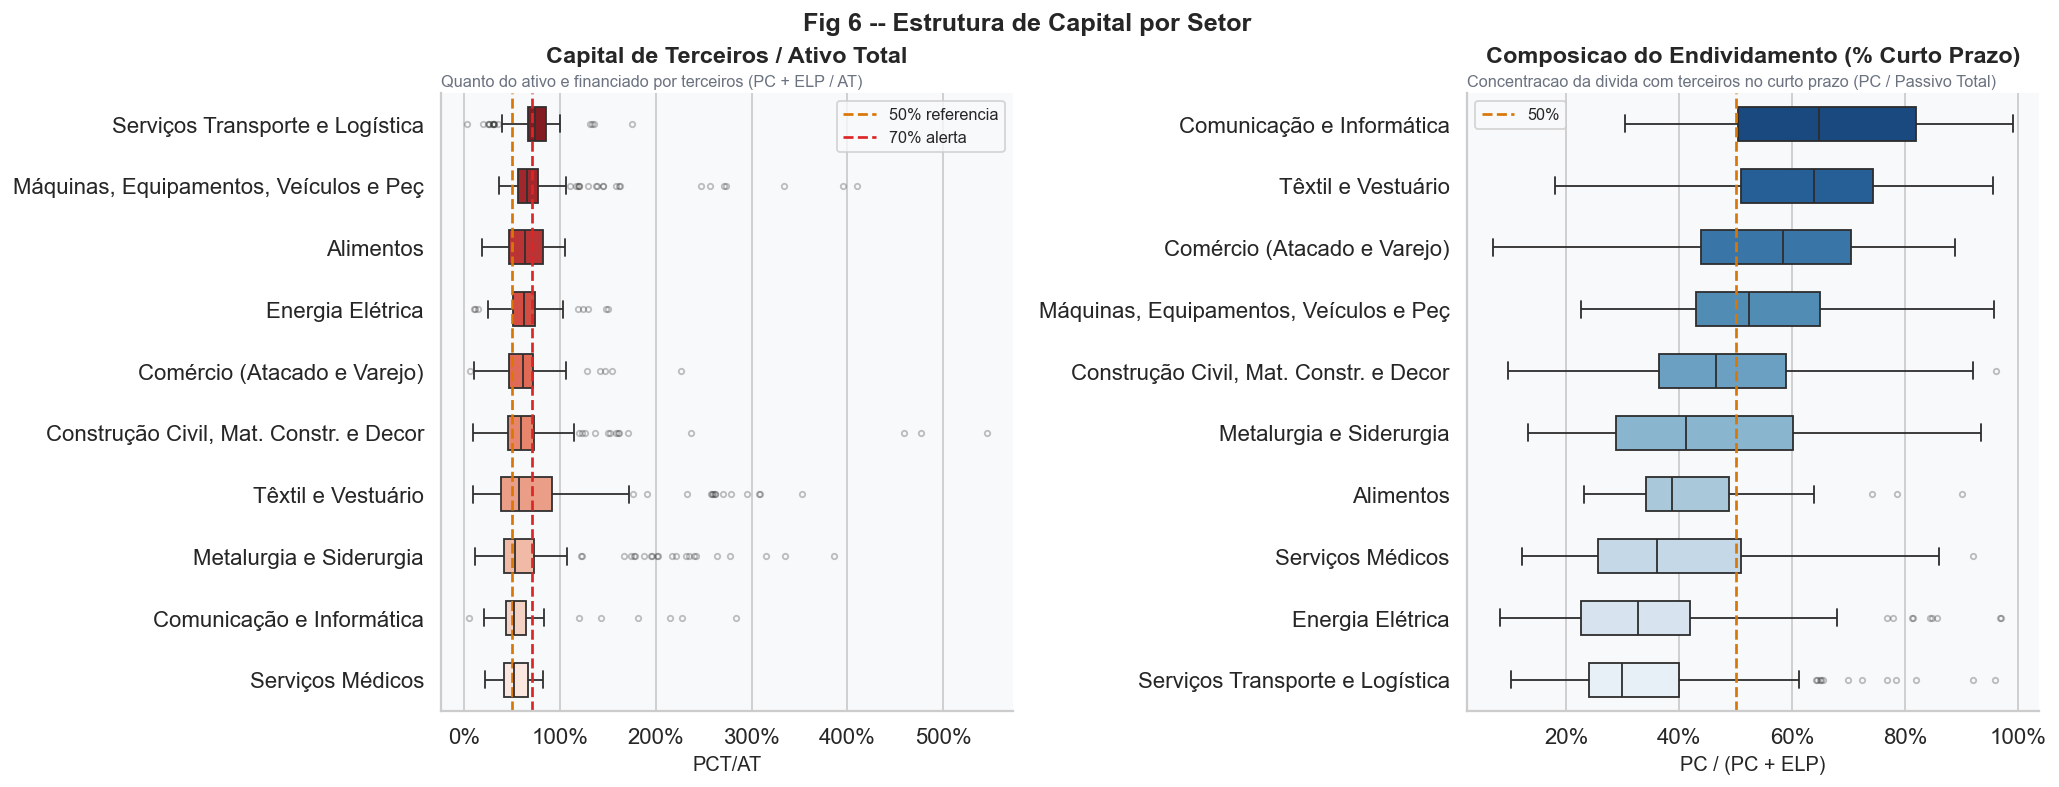

In [9]:
# ── 3a. Estrutura de capital: PCT/AT mediana por setor ───────────────────────
end_data = df_top.copy()
order_end = (end_data.groupby('SETOR_LABEL')['IND_PCT_AT']
             .median().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCT/AT
sns.boxplot(
    data=end_data, y='SETOR_LABEL', x='IND_PCT_AT',
    order=order_end, palette='Reds_r', width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
    ax=axes[0]
)
axes[0].axvline(0.5, color=C_ORANGE, linestyle='--', lw=1.5, label='50% referencia')
axes[0].axvline(0.7, color=C_RED,    linestyle='--', lw=1.5, label='70% alerta')
axes[0].set_title('Capital de Terceiros / Ativo Total')
add_subtitle(axes[0], 'Quanto do ativo e financiado por terceiros (PC + ELP / AT)')
axes[0].set_xlabel('PCT/AT')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
axes[0].legend(fontsize=9)

# Composicao de Endividamento (% no CP)
order_comp = (end_data.groupby('SETOR_LABEL')['IND_COMPOSICAO_ENDIV']
              .median().sort_values(ascending=False).index)
sns.boxplot(
    data=end_data, y='SETOR_LABEL', x='IND_COMPOSICAO_ENDIV',
    order=order_comp, palette='Blues_r', width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
    ax=axes[1]
)
axes[1].axvline(0.5, color=C_ORANGE, linestyle='--', lw=1.5, label='50%')
axes[1].set_title('Composicao do Endividamento (% Curto Prazo)')
add_subtitle(axes[1], 'Concentracao da divida com terceiros no curto prazo (PC / Passivo Total)')
axes[1].set_xlabel('PC / (PC + ELP)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Fig 6 -- Estrutura de Capital por Setor', y=1.01, fontsize=14, fontweight='bold')
plt.show()


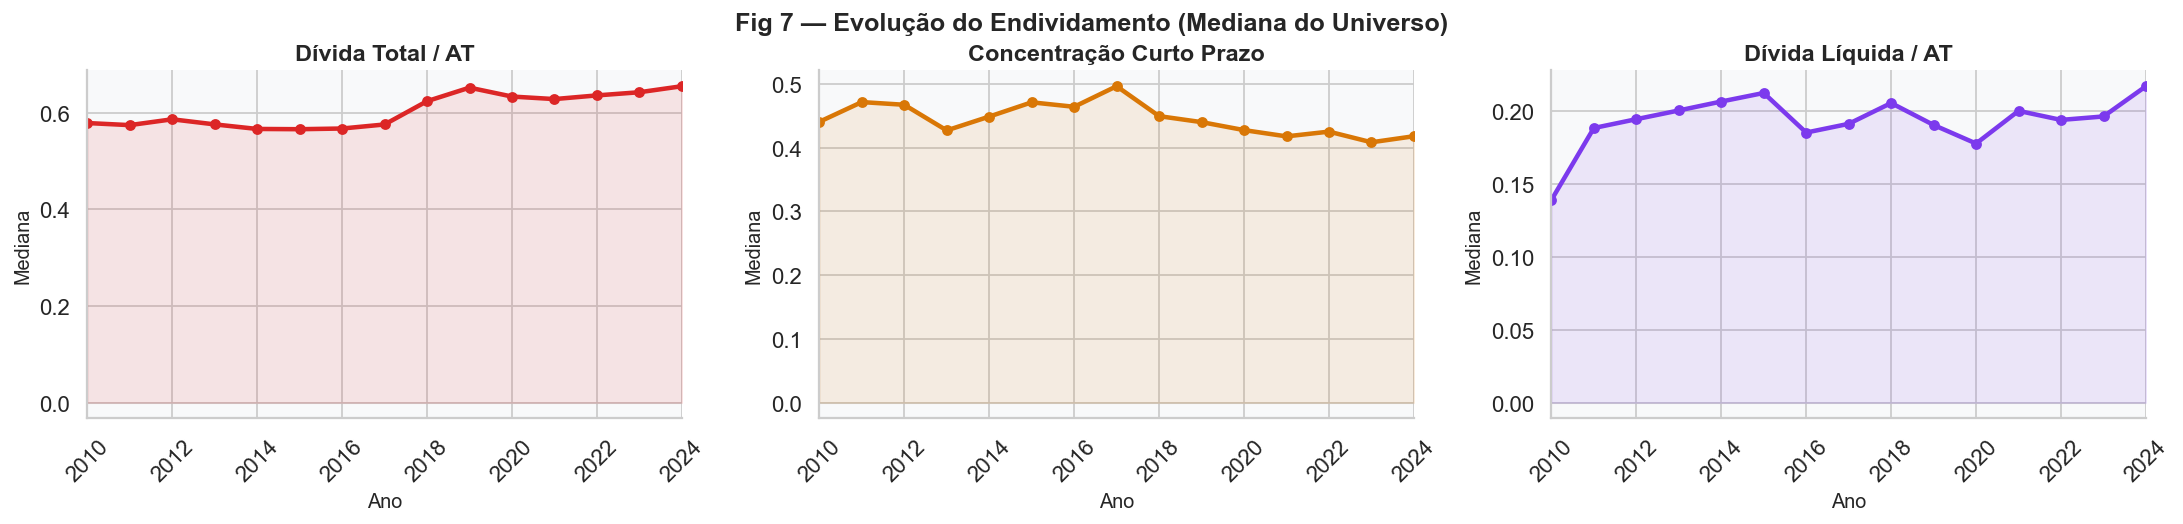

In [10]:
# ── 3b. Evolução Dívida Líquida como % do Ativo Total ────────────────────────
df['IND_DL_AT'] = df['AUX_DIVIDA_LIQUIDA'] / df['V01_ATIVO_TOTAL']
dl_ts = df.groupby('ANO')[['IND_PCT_AT','IND_COMPOSICAO_ENDIV','IND_DL_AT']].median()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
indicadores_end = [
    ('IND_PCT_AT',          'PCT/AT',         C_RED,    'Dívida Total / AT'),
    ('IND_COMPOSICAO_ENDIV','Composição CP',  C_ORANGE, 'Concentração Curto Prazo'),
    ('IND_DL_AT',           'Dívida Líq./AT', C_PURPLE, 'Dívida Líquida / AT'),
]
for ax, (col, label, cor, title) in zip(axes, indicadores_end):
    ax.plot(dl_ts.index, dl_ts[col], color=cor, linewidth=2.5, marker='o', markersize=5)
    ax.fill_between(dl_ts.index, dl_ts[col], alpha=0.1, color=cor)
    ax.set_title(title)
    ax.set_xlabel('Ano')
    ax.set_ylabel('Mediana')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlim(dl_ts.index.min(), dl_ts.index.max())

plt.tight_layout()
plt.suptitle('Fig 7 — Evolução do Endividamento (Mediana do Universo)', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 4 · Margens de Lucro

> **Cascata:** Receita Bruta → **Margem Bruta** (após CPV) → **Margem Operacional** (após despesas) → **Margem Líquida** (após IR/CS)
> Margens negativas são legítimas em períodos de crise ou empresas em fase pré-operacional.


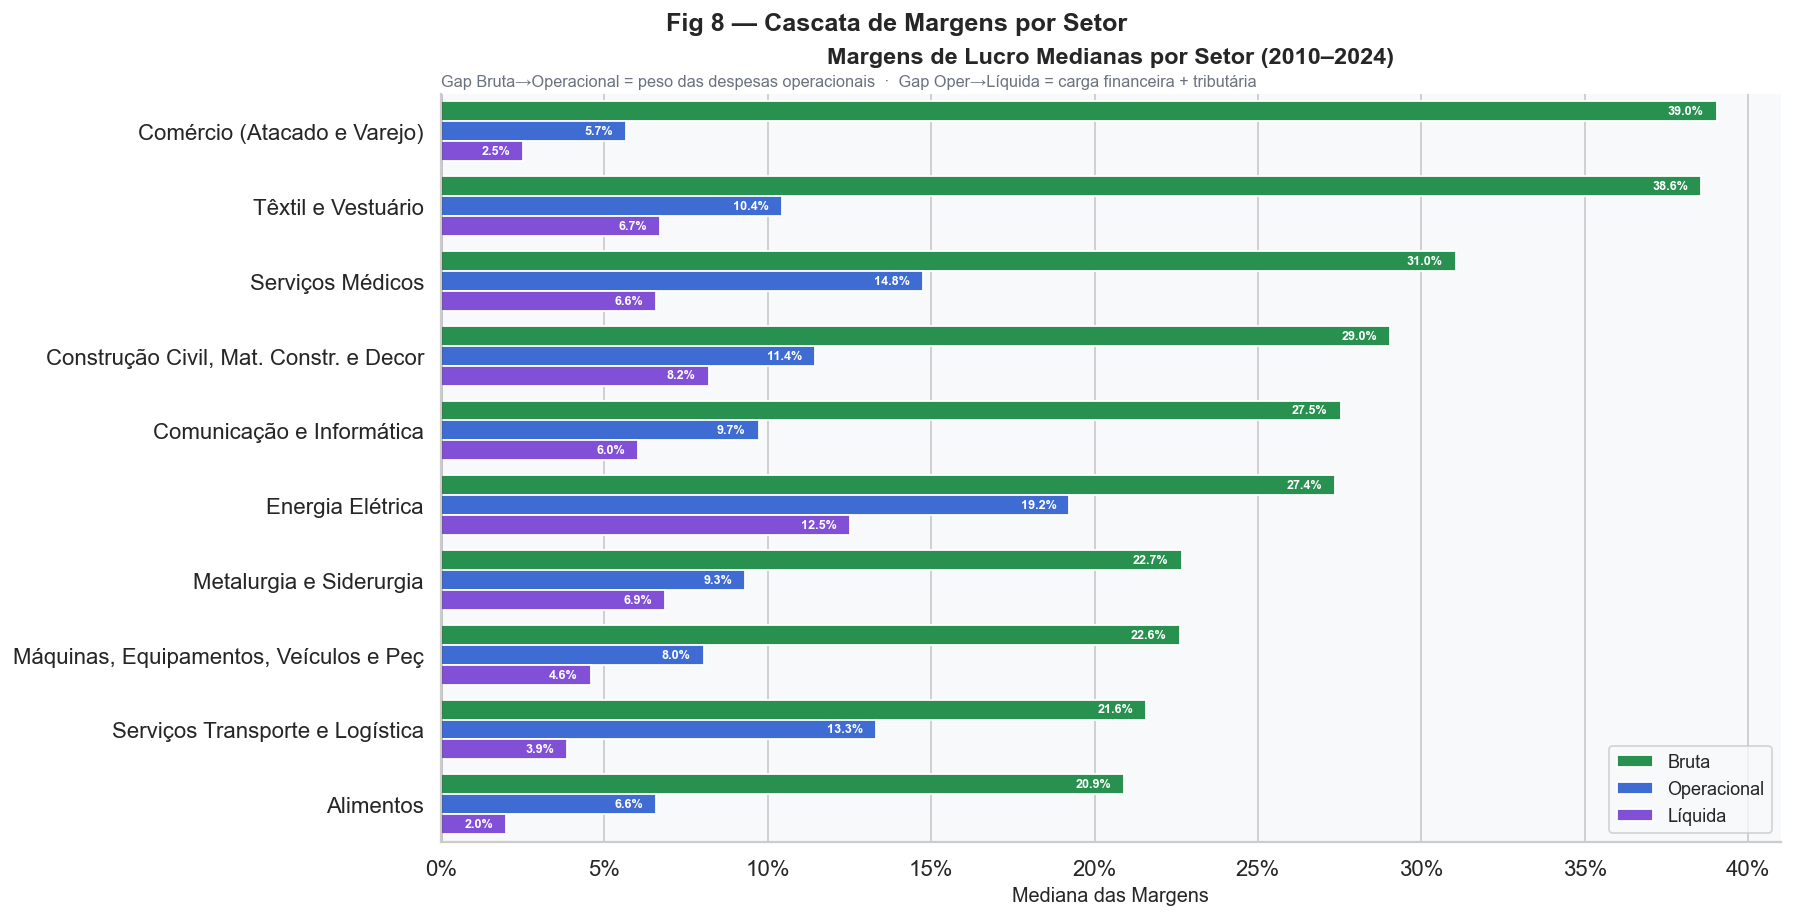

In [11]:
# ── 4a. Comparação das 3 margens por setor ───────────────────────────────────
mar_cols = ['IND_MARGEM_BRUTA', 'IND_MARGEM_OPERACIONAL', 'IND_MARGEM_LIQUIDA']
mar_labels = {'IND_MARGEM_BRUTA': 'Bruta', 'IND_MARGEM_OPERACIONAL': 'Operacional',
              'IND_MARGEM_LIQUIDA': 'Líquida'}

mar_med = (df_top.groupby('SETOR_LABEL')[mar_cols]
           .median()
           .rename(columns=mar_labels)
           .sort_values('Bruta', ascending=False))

mar_melt = mar_med.reset_index().melt(id_vars='SETOR_LABEL', var_name='Margem', value_name='Mediana')

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=mar_melt, x='Mediana', y='SETOR_LABEL', hue='Margem',
    order=mar_med.index, palette=[C_GREEN, C_BLUE, C_PURPLE],
    ax=ax
)
ax.axvline(0, color='black', lw=0.8)

# ── Rotulos na extremidade interna de cada barra ──────────────────────────────
for bar in ax.patches:
    val = bar.get_width()
    if abs(val) < 0.005:          # barra muito pequena: pular
        continue
    # Extremidade interna = lado oposto ao zero
    x_pos  = val - 0.004 if val > 0 else val + 0.004
    ha      = 'right'  if val > 0 else 'left'
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1%}',
        ha=ha, va='center',
        fontsize=7, color='white', fontweight='bold'
    )

ax.set_title('Margens de Lucro Medianas por Setor (2010–2024)')
add_subtitle(ax, 'Gap Bruta→Operacional = peso das despesas operacionais  ·  Gap Oper→Líquida = carga financeira + tributária')
ax.set_xlabel('Mediana das Margens')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.legend(title='')
plt.tight_layout()
plt.suptitle('Fig 8 — Cascata de Margens por Setor', y=1.01, fontsize=14, fontweight='bold')
plt.show()


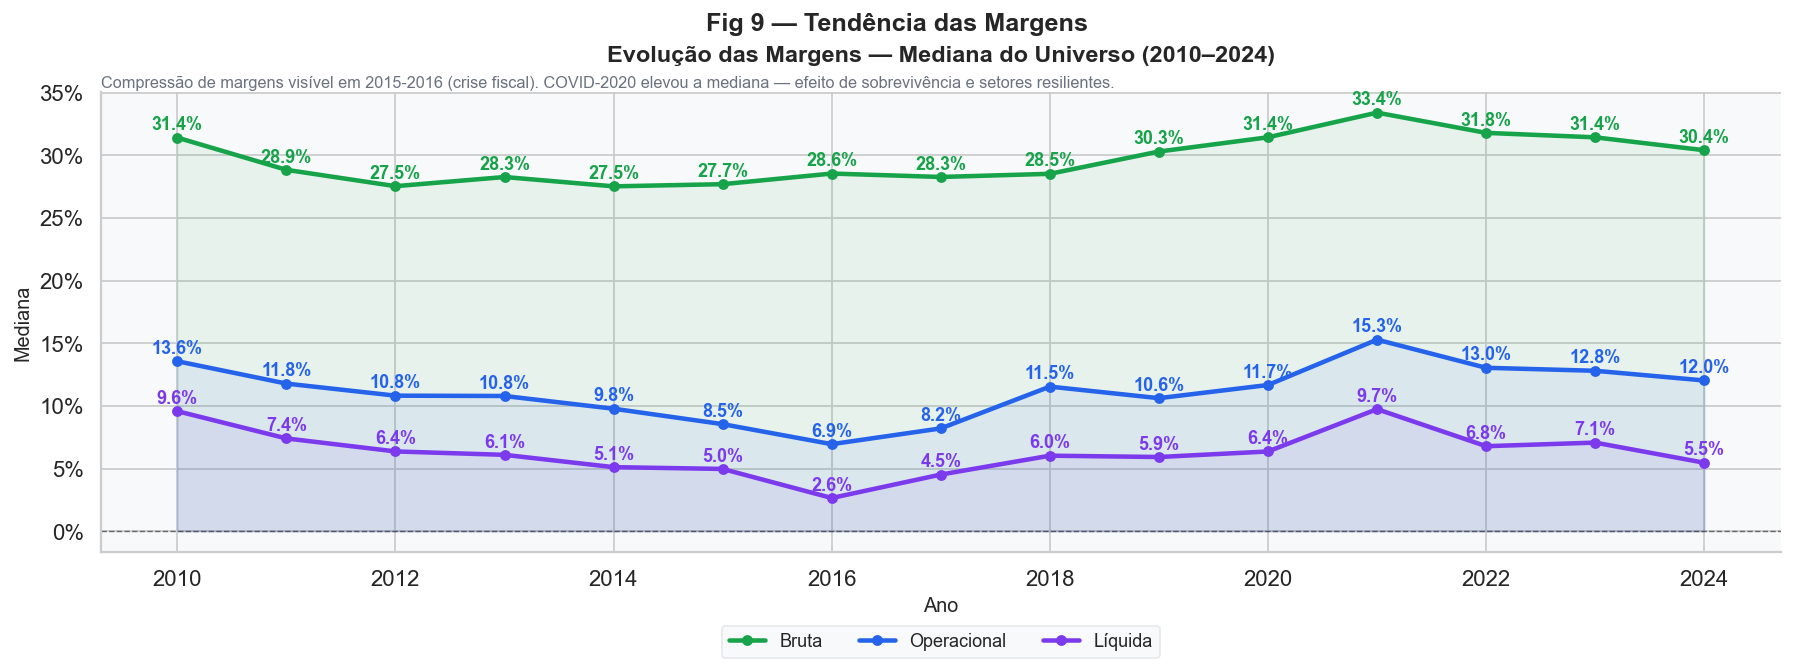

In [12]:
# ── 4b. Evolução temporal das 3 margens ──────────────────────────────────────
mar_ts = df.groupby('ANO')[mar_cols].median()

fig, ax = plt.subplots(figsize=(14, 5))
colors_mar = [C_GREEN, C_BLUE, C_PURPLE]
for col, label, cor in zip(mar_cols, ['Bruta', 'Operacional', 'Líquida'], colors_mar):
    ax.plot(mar_ts.index, mar_ts[col], linewidth=2.5, marker='o',
            markersize=5, color=cor, label=label)
    ax.fill_between(mar_ts.index, mar_ts[col], alpha=0.07, color=cor)

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)

# ── Rotulos acima de cada marcador ────────────────────────────────────────────
for col, cor in zip(mar_cols, colors_mar):
    for ano, val in mar_ts[col].items():
        if pd.isna(val):
            continue
        ax.text(ano, val + 0.003, f'{val:.1%}',
                ha='center', va='bottom', fontsize=10,
                color=cor, fontweight='bold')
ax.set_title('Evolução das Margens — Mediana do Universo (2010–2024)')
add_subtitle(ax, 'Compressão de margens visível em 2015-2016 (crise fiscal). COVID-2020 elevou a mediana — efeito de sobrevivência e setores resilientes.')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.set_xlabel('Ano')
ax.set_ylabel('Mediana')
ax.legend(
    title='', ncol=3,
    loc='upper center', bbox_to_anchor=(0.5, -0.14),
    frameon=True, framealpha=0.9, edgecolor='#E5E7EB'
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.suptitle('Fig 9 — Tendência das Margens', y=1.01, fontsize=14, fontweight='bold')
plt.show()


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


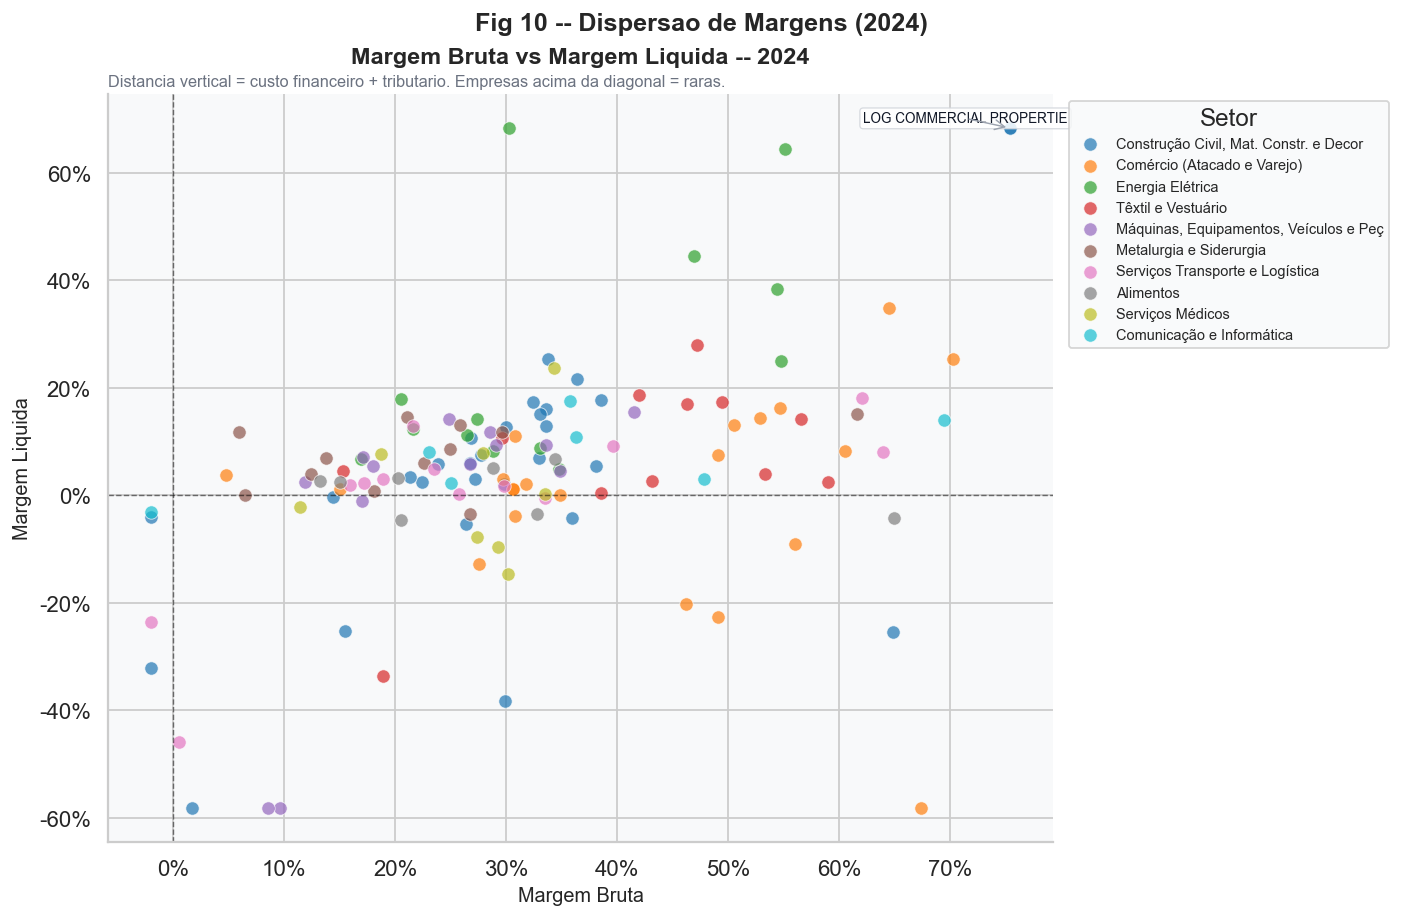

In [13]:
# ── 4c. Scatter: Margem Bruta vs Margem Liquida (ultimo ano -- outliers anotados) ──
from adjustText import adjust_text

ano_max = df['ANO'].max()
df_last = df[df['ANO'] == ano_max].copy()
df_last['MB_VIZ'] = clip_viz(df_last['IND_MARGEM_BRUTA'])
df_last['ML_VIZ'] = clip_viz(df_last['IND_MARGEM_LIQUIDA'])
df_last_top = df_last[df_last['SETOR_LABEL'].isin(TOP10)].copy()

fig, ax = plt.subplots(figsize=(11, 7))
palette_scatter = sns.color_palette('tab10', len(TOP10))
for i, setor in enumerate(TOP10):
    sub = df_last_top[df_last_top['SETOR_LABEL'] == setor]
    ax.scatter(sub['MB_VIZ'], sub['ML_VIZ'], label=setor,
               color=palette_scatter[i], alpha=0.7, s=55, edgecolors='white', linewidth=0.5)

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)

# ── Outliers: distancia euclidiana normalizada da mediana nos dois eixos ──────
df_annot = df_last_top[['RAZAO_SOCIAL', 'MB_VIZ', 'ML_VIZ']].dropna()
med_mb  = df_annot['MB_VIZ'].median()
med_ml  = df_annot['ML_VIZ'].median()
std_mb  = df_annot['MB_VIZ'].std()
std_ml  = df_annot['ML_VIZ'].std()
df_annot['dist'] = np.sqrt(
    ((df_annot['MB_VIZ'] - med_mb) / std_mb) ** 2 +
    ((df_annot['ML_VIZ'] - med_ml) / std_ml) ** 2
)

texts = []
for _, row in df_annot.nlargest(1, 'dist').iterrows():
    t = ax.text(
        row['MB_VIZ'], row['ML_VIZ'],
        row['RAZAO_SOCIAL'][:24],
        fontsize=7.5, color='#111827',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  alpha=0.88, edgecolor='#D1D5DB', linewidth=0.7)
    )
    texts.append(t)

adjust_text(
    texts,
    x=df_annot['MB_VIZ'].values,
    y=df_annot['ML_VIZ'].values,
    ax=ax,
    expand_text=(1.3, 1.5),
    expand_points=(1.4, 1.6),
    arrowprops=dict(arrowstyle='->', color='#9CA3AF', lw=0.8)
)

ax.set_xlabel('Margem Bruta')
ax.set_ylabel('Margem Liquida')
ax.set_title(f'Margem Bruta vs Margem Liquida -- {ano_max}')
add_subtitle(ax, 'Distancia vertical = custo financeiro + tributario. Empresas acima da diagonal = raras.')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.legend(title='Setor', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.suptitle(f'Fig 10 -- Dispersao de Margens ({ano_max})', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 5 · Rentabilidade

> **ROA** = Lucro Líquido / Ativo Total — eficiência dos ativos
> **ROE** = Lucro Líquido / PL — retorno ao acionista
> **ROI** = Lucro Líquido / Capital Investido (PL + Passivo Oneroso) — retorno sobre capital total


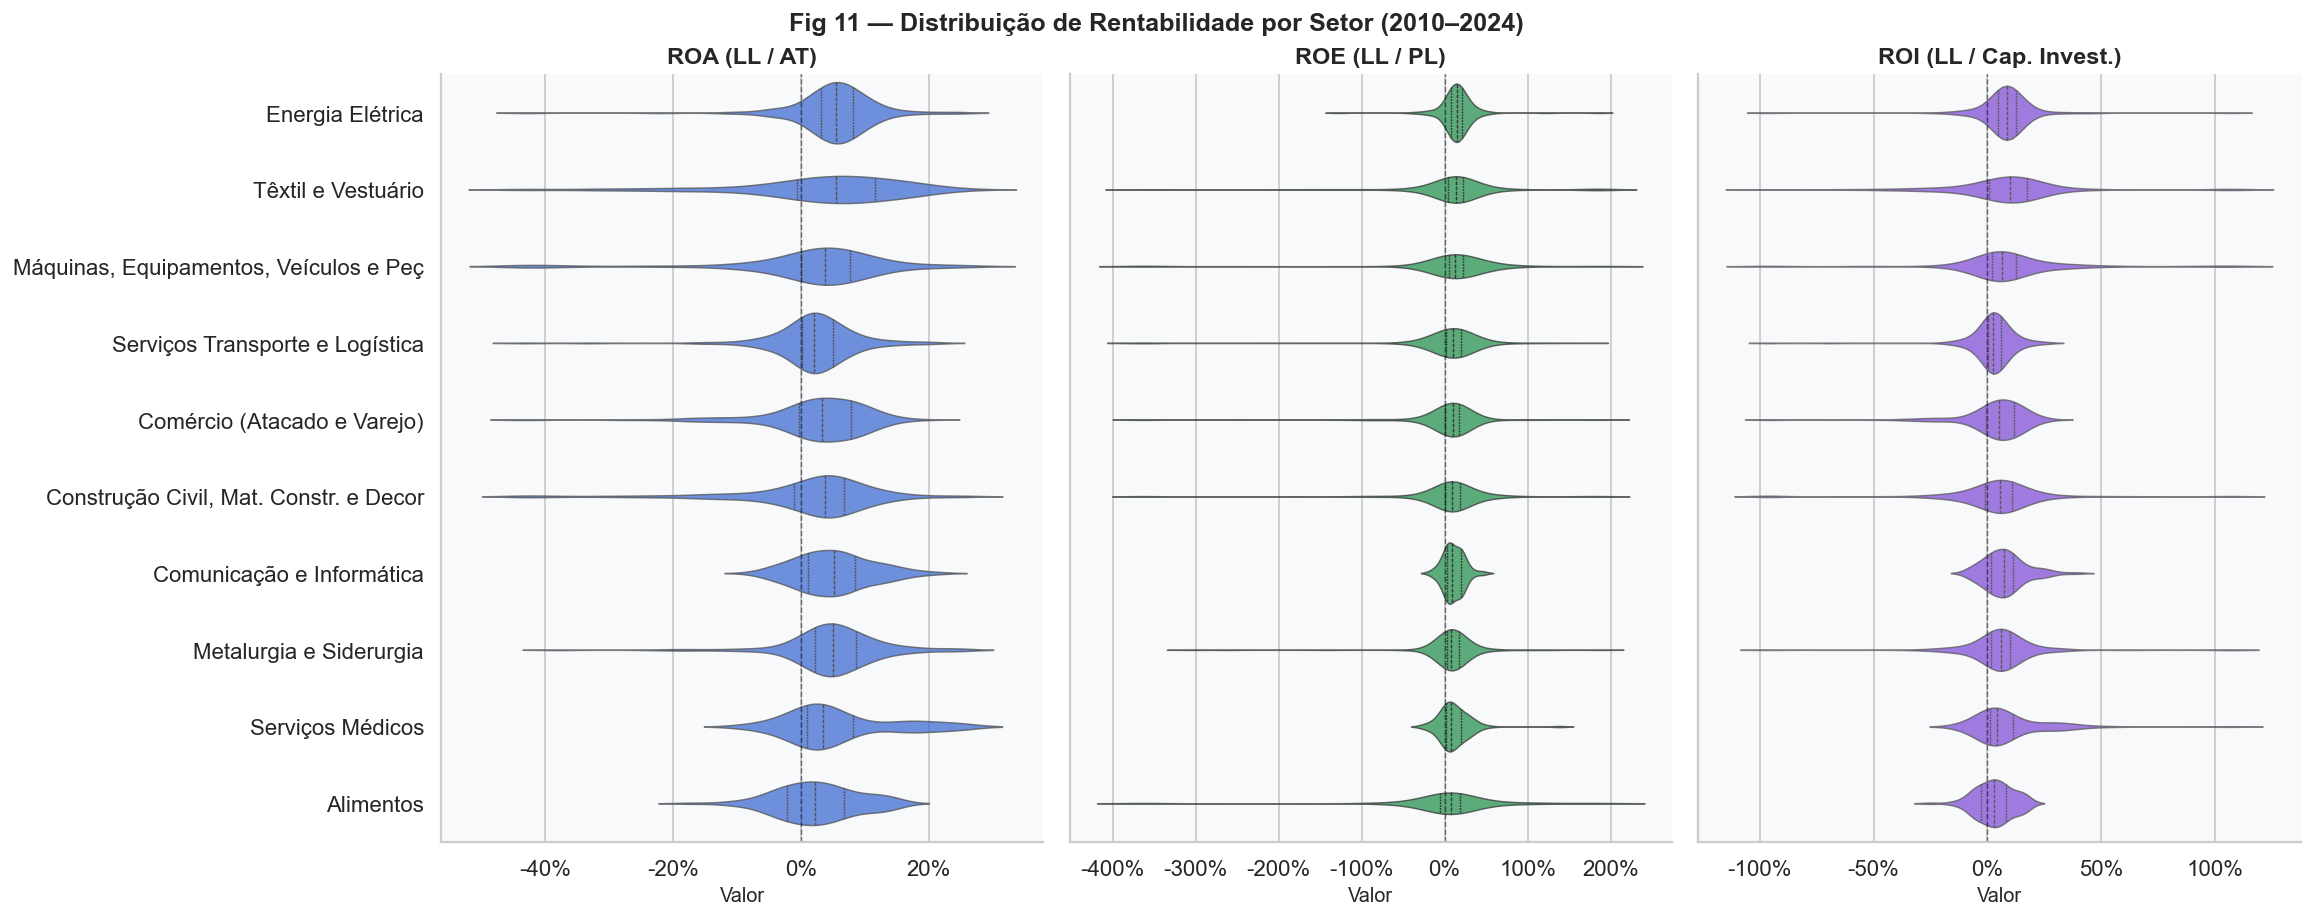

In [14]:
# ── 5a. Violinplot ROA / ROE / ROI por setor ─────────────────────────────────
rent_cols = ['IND_ROA', 'IND_ROE', 'IND_ROI']
df_rent = df_top.copy()
for col in rent_cols:
    df_rent[col] = clip_viz(df_rent[col], lo=0.01, hi=0.99)

order_roe = df_rent.groupby('SETOR_LABEL')['IND_ROE'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
configs = [
    ('IND_ROA', 'ROA (LL / AT)',  C_BLUE),
    ('IND_ROE', 'ROE (LL / PL)',  C_GREEN),
    ('IND_ROI', 'ROI (LL / Cap. Invest.)', C_PURPLE),
]
for ax, (col, title, cor) in zip(axes, configs):
    sns.violinplot(
        data=df_rent, y='SETOR_LABEL', x=col,
        order=order_roe, color=cor, alpha=0.75, inner='quartile',
        linewidth=0.8, ax=ax
    )
    ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Valor')
    ax.set_ylabel('' if ax != axes[0] else '')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))

plt.tight_layout()
plt.suptitle('Fig 11 — Distribuição de Rentabilidade por Setor (2010–2024)', y=1.01, fontsize=14, fontweight='bold')
plt.show()


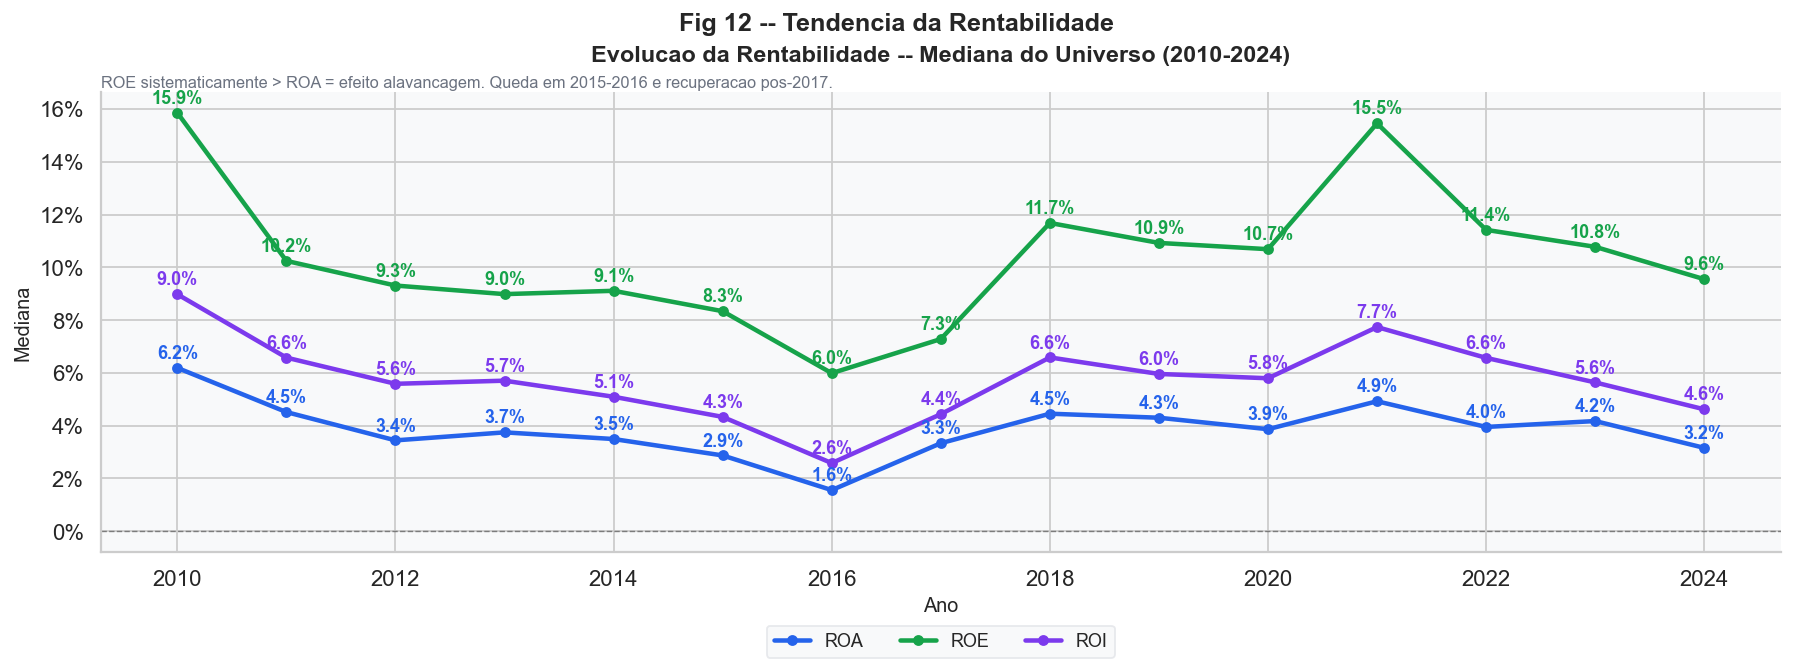

In [15]:
# ── 5b. Evolucao ROA/ROE/ROI -- Mediana do universo ─────────────────────────
rent_ts = df.groupby('ANO')[rent_cols].median()

fig, ax = plt.subplots(figsize=(14, 5))
cores = [C_BLUE, C_GREEN, C_PURPLE]
labels_rent = ['ROA', 'ROE', 'ROI']
for col, label, cor in zip(rent_cols, labels_rent, cores):
    ax.plot(rent_ts.index, rent_ts[col], linewidth=2.5, marker='o',
            markersize=5, color=cor, label=label)

# ── Rotulos acima de cada marcador ────────────────────────────────────────────
for col, cor in zip(rent_cols, cores):
    for ano, val in rent_ts[col].items():
        if pd.isna(val):
            continue
        ax.text(ano, val + 0.002, f'{val:.1%}',
                ha='center', va='bottom', fontsize=10, color=cor, fontweight='bold')

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.set_title('Evolucao da Rentabilidade -- Mediana do Universo (2010-2024)')
add_subtitle(ax, 'ROE sistematicamente > ROA = efeito alavancagem. Queda em 2015-2016 e recuperacao pos-2017.')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.set_xlabel('Ano')
ax.set_ylabel('Mediana')
ax.legend(
    title='', ncol=3,
    loc='upper center', bbox_to_anchor=(0.5, -0.14),
    frameon=True, framealpha=0.9, edgecolor='#E5E7EB'
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.suptitle('Fig 12 -- Tendencia da Rentabilidade', y=1.01, fontsize=14, fontweight='bold')
plt.show()


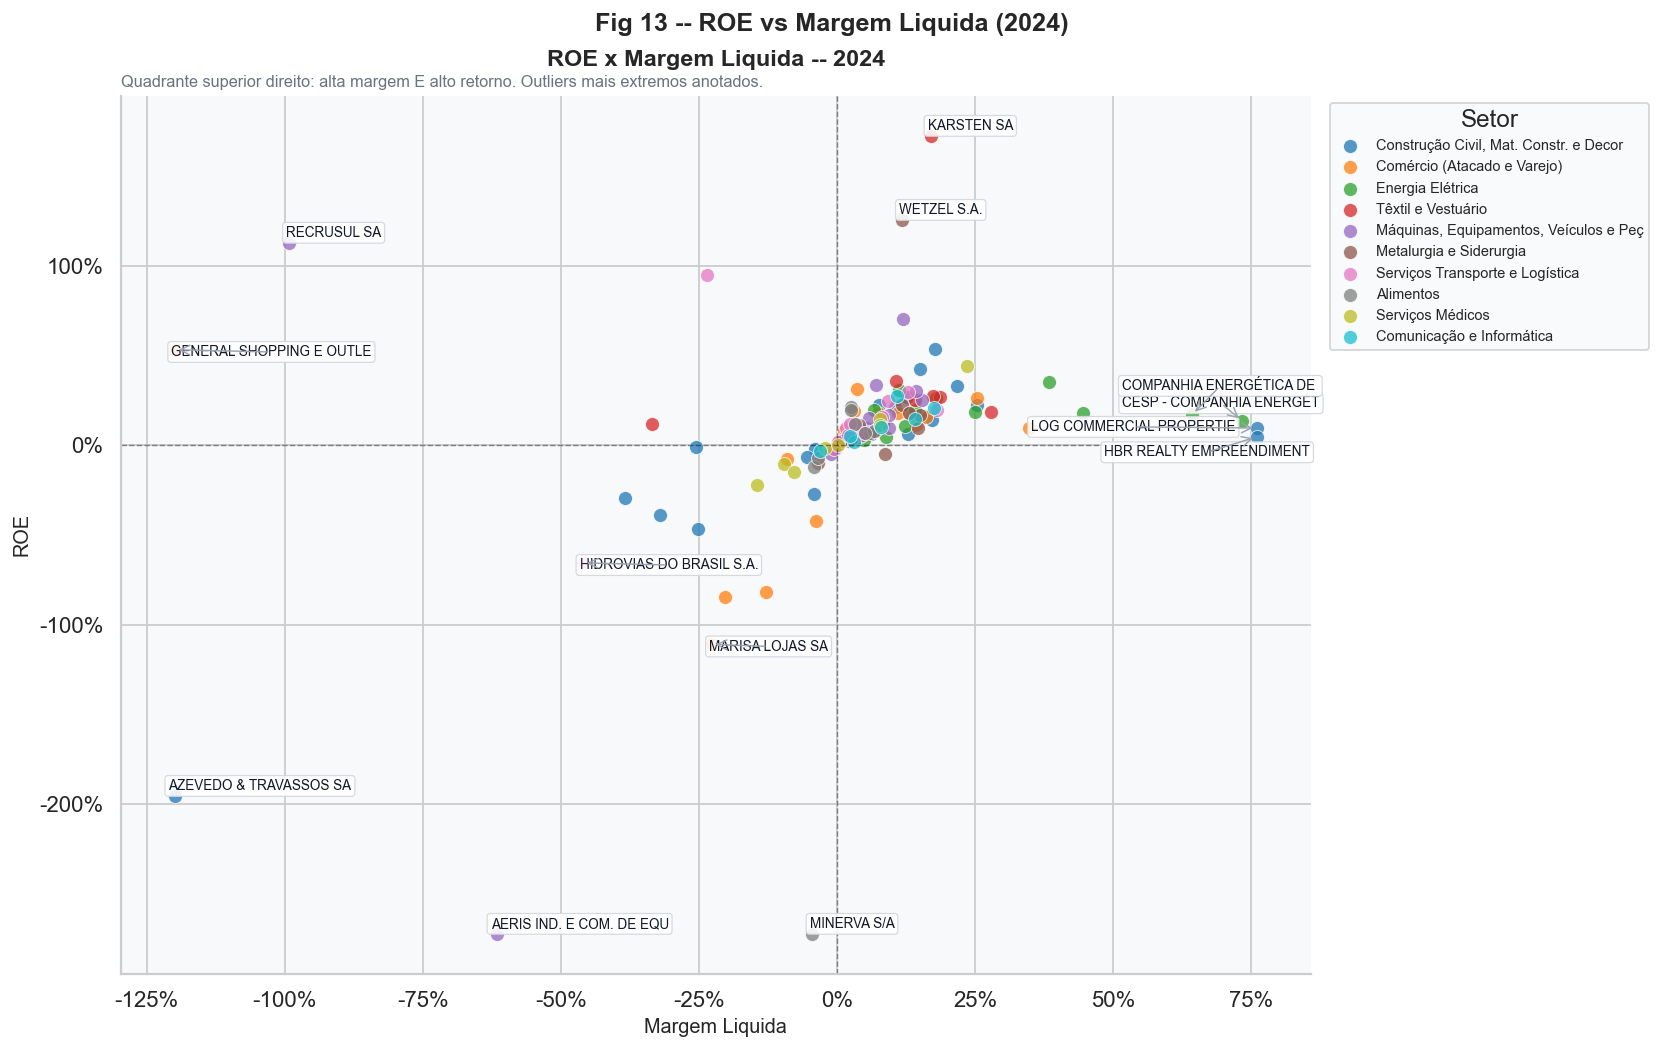

In [16]:
# ── 5c. Scatter: ROE x Margem Liquida (ultimo ano -- outliers anotados) ──────
from adjustText import adjust_text

df_l = df_last.copy()
df_l['ROE_VIZ'] = clip_viz(df_l['IND_ROE'],           lo=0.01, hi=0.99)
df_l['ML_VIZ2'] = clip_viz(df_l['IND_MARGEM_LIQUIDA'], lo=0.01, hi=0.99)
df_l_top = df_l[df_l['SETOR_LABEL'].isin(TOP10)].copy()

fig, ax = plt.subplots(figsize=(13, 8))
for i, setor in enumerate(TOP10):
    sub = df_l_top[df_l_top['SETOR_LABEL'] == setor]
    ax.scatter(sub['ML_VIZ2'], sub['ROE_VIZ'], label=setor,
               color=palette_scatter[i], alpha=0.75, s=60, edgecolors='white', linewidth=0.5)

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)

# ── Selecionar outliers por distancia euclidiana normalizada da mediana ────────
df_annot = df_l_top[['RAZAO_SOCIAL', 'ML_VIZ2', 'ROE_VIZ']].dropna()
med_ml  = df_annot['ML_VIZ2'].median()
med_roe = df_annot['ROE_VIZ'].median()
std_ml  = df_annot['ML_VIZ2'].std()
std_roe = df_annot['ROE_VIZ'].std()
df_annot['dist'] = np.sqrt(
    ((df_annot['ML_VIZ2']  - med_ml)  / std_ml) ** 2 +
    ((df_annot['ROE_VIZ']  - med_roe) / std_roe) ** 2
)
outliers = df_annot.nlargest(13, 'dist')

# ── Criar textos sem posicao fixa -- adjust_text resolve sobreposicoes ─────────
texts = []
for _, row in outliers.iterrows():
    nome = row['RAZAO_SOCIAL'][:24]
    t = ax.text(
        row['ML_VIZ2'], row['ROE_VIZ'], nome,
        fontsize=7.5, color='#111827',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  alpha=0.88, edgecolor='#D1D5DB', linewidth=0.7)
    )
    texts.append(t)

adjust_text(
    texts,
    x=df_annot['ML_VIZ2'].values,
    y=df_annot['ROE_VIZ'].values,
    ax=ax,
    expand_text=(1.3, 1.5),
    expand_points=(1.4, 1.6),
    arrowprops=dict(arrowstyle='->', color='#9CA3AF', lw=0.8)
)

ax.set_xlabel('Margem Liquida')
ax.set_ylabel('ROE')
ax.set_title(f'ROE x Margem Liquida -- {ano_max}')
add_subtitle(ax, 'Quadrante superior direito: alta margem E alto retorno. Outliers mais extremos anotados.')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.legend(title='Setor', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.suptitle(f'Fig 13 -- ROE vs Margem Liquida ({ano_max})', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 6 · Atividade — Prazos Médios e Ciclos

> **PMRE** = dias para vender o estoque · **PMRV** = dias para receber dos clientes · **PMPC** = dias para pagar fornecedores
> **Ciclo Financeiro** = PMRE + PMRV − PMPC — dias em que o capital fica **preso** (negativo = empresa se autofinancia)


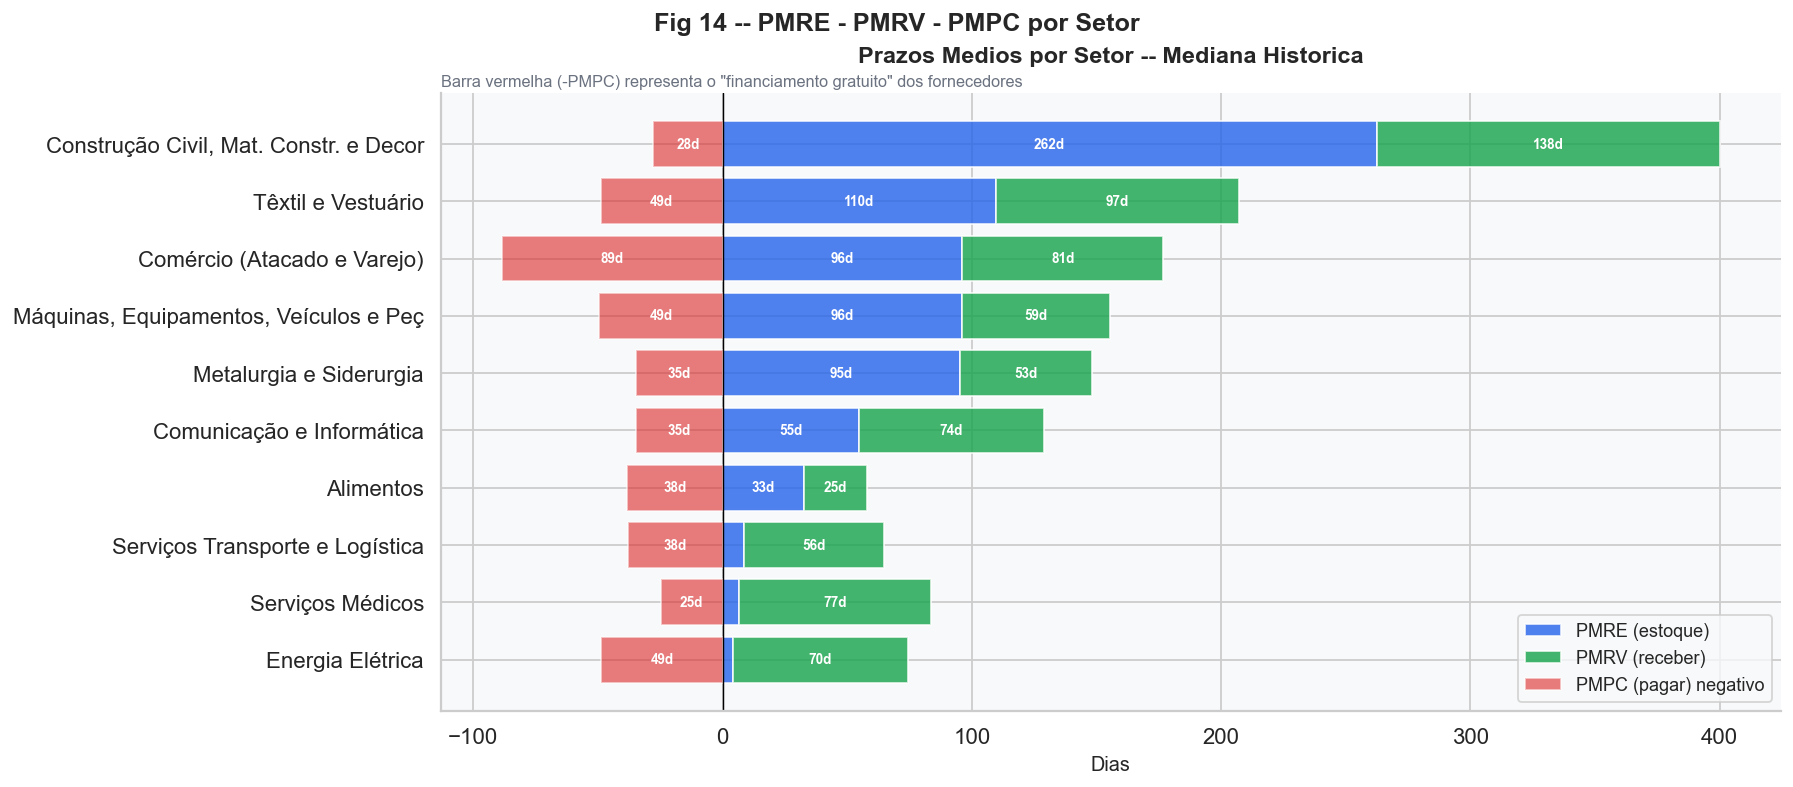

In [17]:
# ── 6a. Prazos medios medianos por setor (stacked bar horizontal) ─────────────
pmre_med = df_top.groupby('SETOR_LABEL')[['IND_PMRE','IND_PMRV','IND_PMPC']].median()
pmre_med = pmre_med.dropna(subset=['IND_PMRE'])
pmre_med = pmre_med.sort_values('IND_PMRE', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
y_pos      = range(len(pmre_med))
labels_set = pmre_med.index.tolist()

bars_re = ax.barh(y_pos, pmre_med['IND_PMRE'], color=C_BLUE,  alpha=0.8, label='PMRE (estoque)')
bars_rv = ax.barh(y_pos, pmre_med['IND_PMRV'], left=pmre_med['IND_PMRE'],
                  color=C_GREEN, alpha=0.8, label='PMRV (receber)')
bars_pc = ax.barh(y_pos, -pmre_med['IND_PMPC'], color=C_RED,  alpha=0.6, label='PMPC (pagar) negativo')
ax.axvline(0, color='black', lw=0.8)

# ── Rotulos dentro de cada barra ──────────────────────────────────────────────
MIN_WIDTH = 12   # largura minima (dias) para caber rotulo dentro da barra

for i, (_, row) in enumerate(pmre_med.iterrows()):
    pmre, pmrv, pmpc = row['IND_PMRE'], row['IND_PMRV'], row['IND_PMPC']

    # PMRE: centro = pmre/2
    if pmre >= MIN_WIDTH:
        ax.text(pmre / 2, i, f'{pmre:.0f}d',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

    # PMRV: centro = pmre + pmrv/2
    if pmrv >= MIN_WIDTH:
        ax.text(pmre + pmrv / 2, i, f'{pmrv:.0f}d',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

    # PMPC: barra vai de 0 a -pmpc; centro = -pmpc/2
    if pmpc >= MIN_WIDTH:
        ax.text(-pmpc / 2, i, f'{pmpc:.0f}d',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels_set)
ax.set_xlabel('Dias')
ax.set_title('Prazos Medios por Setor -- Mediana Historica')
add_subtitle(ax, 'Barra vermelha (-PMPC) representa o "financiamento gratuito" dos fornecedores')
ax.legend(loc='lower right')

plt.tight_layout()
plt.suptitle('Fig 14 -- PMRE - PMRV - PMPC por Setor', y=1.01, fontsize=14, fontweight='bold')
plt.show()


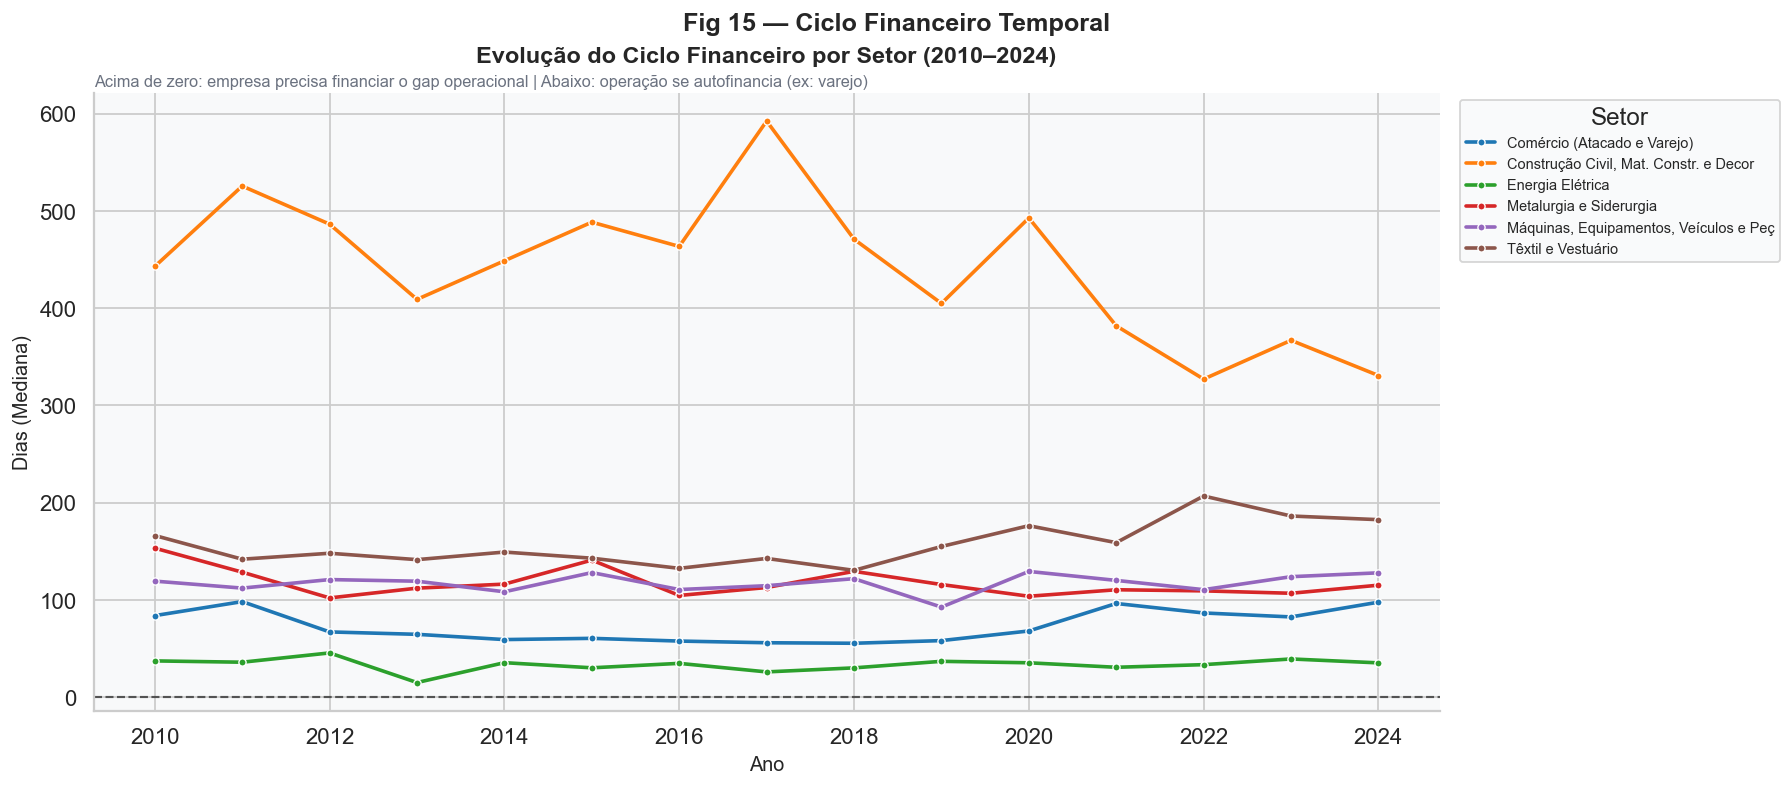

In [18]:
# ── 6b. Evolução do Ciclo Financeiro por setor (top 6) ───────────────────────
top6 = [s for s in TOP10 if df_top[df_top['SETOR_LABEL']==s]['IND_CICLO_FINANCEIRO'].notna().sum() > 10][:6]
ciclo_ts = (df_top[df_top['SETOR_LABEL'].isin(top6)]
            .groupby(['ANO','SETOR_LABEL'])['IND_CICLO_FINANCEIRO']
            .median().reset_index())

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=ciclo_ts, x='ANO', y='IND_CICLO_FINANCEIRO',
             hue='SETOR_LABEL', palette='tab10', linewidth=2.0, marker='o', markersize=4, ax=ax)
ax.axhline(0, color='black', lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('Evolução do Ciclo Financeiro por Setor (2010–2024)')
add_subtitle(ax, 'Acima de zero: empresa precisa financiar o gap operacional | Abaixo: operação se autofinancia (ex: varejo)')
ax.set_xlabel('Ano')
ax.set_ylabel('Dias (Mediana)')
ax.legend(title='Setor', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.suptitle('Fig 15 — Ciclo Financeiro Temporal', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---

## 7 · Capital de Giro — Modelo Fleuriet

> O modelo Fleuriet classifica empresas em 6 perfis financeiros com base em **CGL** (Capital de Giro Líquido), **NCG** (Necessidade de Capital de Giro) e **ST** (Saldo de Tesouraria).
>
> | Tipo | CGL | NCG | ST | Classificação | Resumo Prático & Analogia |
> |:---:|:---:|:---:|:---:|---|---|
> | I | > 0 | < 0 | > 0 | **Excelente** — excedente de caixa estrutural | A operação se autofinancia e os recursos de longo prazo sobram.<br>**(O Mestre das Finanças:** Salário farto, rotina gera crédito e o banco transborda). |
> | II | > 0 | > 0 | > 0 | **Sólido** — CGL financia folga de caixa | A operação exige dinheiro, mas a boa captação de longo prazo cobre tudo.<br>**(O Organizado:** Custo de vida alto, mas o ótimo salário paga tudo e sobra). |
> | III | > 0 | > 0 | < 0 | **Insatisfatório** — precisa de capital de giro externo | O custo da operação engoliu os recursos de longo prazo. Preso em empréstimos.<br>**(O Deslumbrado:** Bom salário, mas a rotina irresponsável o jogou no cheque especial). |
> | IV | < 0 | > 0 | < 0 | **Alto Risco** — desfinanciado operacionalmente | Erro estrutural grave e operação custosa. Queima de caixa e pré-falência.<br>**(A Bomba Relógio:** Salário não cobre a casa, rotina é cara e vive de juros). |
> | V | < 0 | < 0 | < 0 | **Muito Ruim** — desequilíbrio total | Rombo estrutural gigante. Mesmo espremendo a operação, o caixa fica no vermelho.<br>**(O Malabarista Falido:** Salário não paga o aluguel. Tenta zerar a rotina, mas o banco segue bloqueado). |
> | VI | < 0 | < 0 | > 0 | **Arriscado** — posição frágil com caixa artificial | Ilusão. Operação financiada por terceiros (fornecedores) mascara o déficit estrutural.<br>**(O Falso Rico:** Salário não banca o básico, empurra as contas com a barriga e o saldo atual engana). |


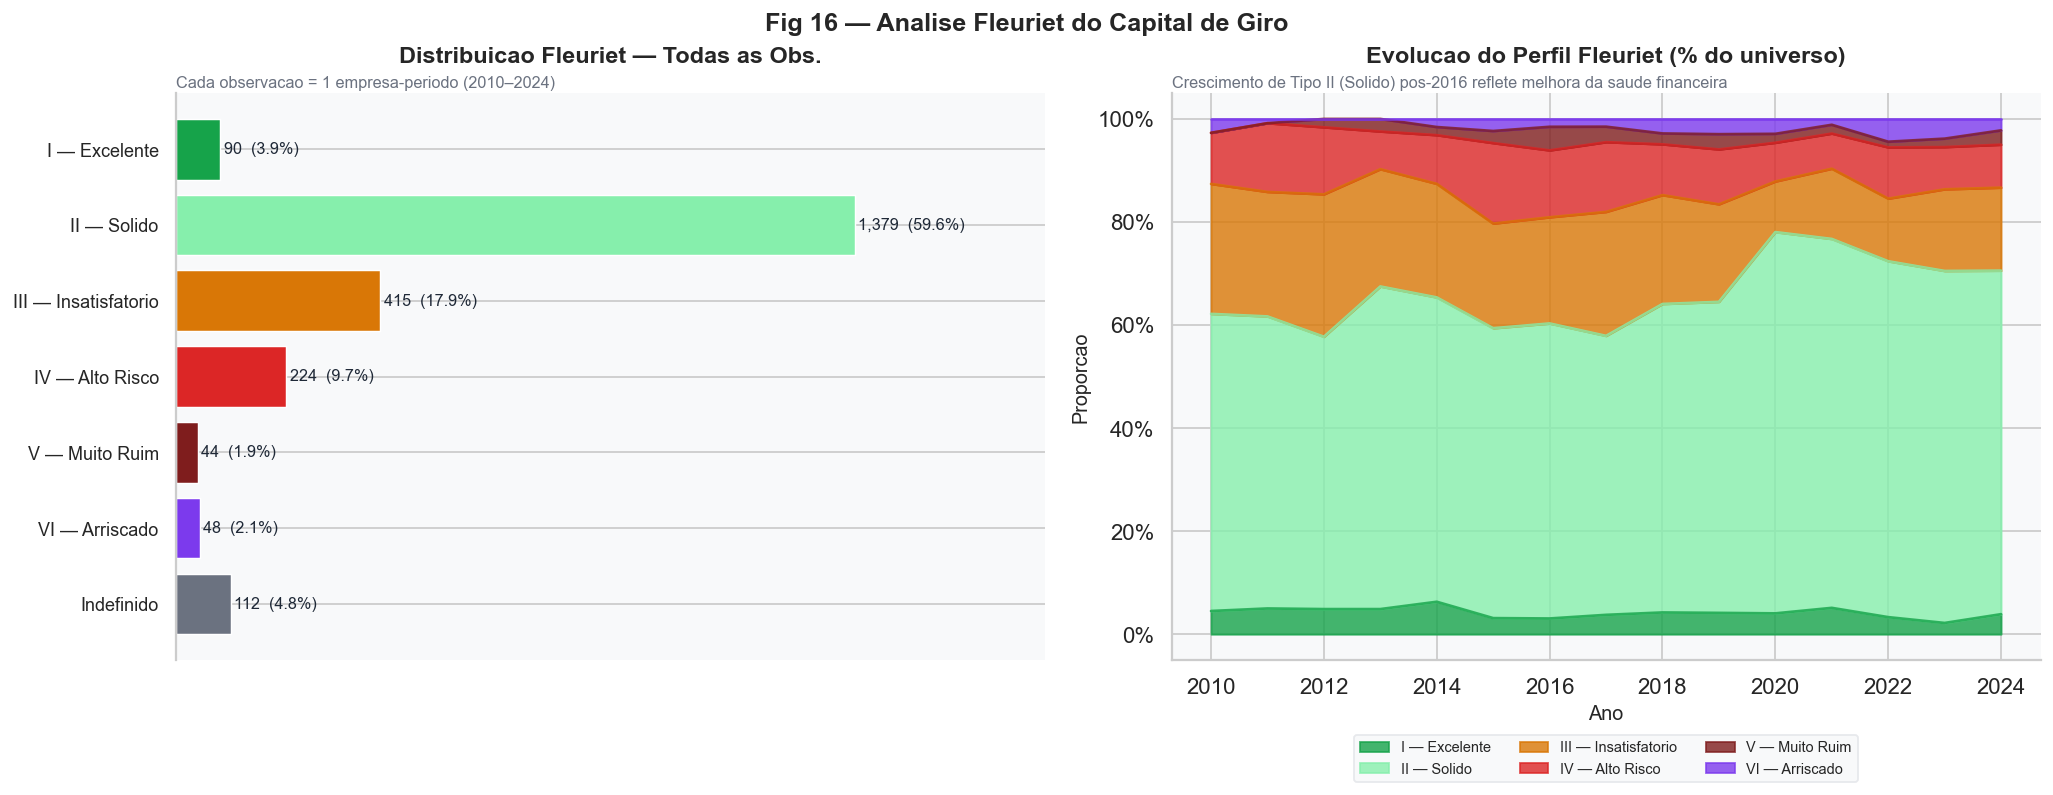

In [19]:
# ── 7a. Classificacao Fleuriet ────────────────────────────────────────────────
def fleuriet_tipo(row):
    cgl = row['IND_CGL']
    ncg = row['IND_NCG']
    st  = row['IND_ST']
    if pd.isna(cgl) or pd.isna(ncg) or pd.isna(st):
        return 'Indefinido'
    if   cgl > 0 and ncg < 0 and st > 0: return 'I — Excelente'
    elif cgl > 0 and ncg > 0 and st > 0: return 'II — Solido'
    elif cgl > 0 and ncg > 0 and st < 0: return 'III — Insatisfatorio'
    elif cgl < 0 and ncg > 0 and st < 0: return 'IV — Alto Risco'
    elif cgl < 0 and ncg < 0 and st < 0: return 'V — Muito Ruim'
    elif cgl < 0 and ncg < 0 and st > 0: return 'VI — Arriscado'
    else:                                 return 'Indefinido'

df['FLEURIET'] = df.apply(fleuriet_tipo, axis=1)

ORDER_FL = ['I — Excelente','II — Solido','III — Insatisfatorio',
            'IV — Alto Risco','V — Muito Ruim','VI — Arriscado','Indefinido']
COLOR_FL  = [C_GREEN, '#86EFAC', C_ORANGE, C_RED, '#7F1D1D', C_PURPLE, C_GRAY]
COLOR_MAP = dict(zip(ORDER_FL, COLOR_FL))

fl_count = (df['FLEURIET']
            .value_counts()
            .reindex([o for o in ORDER_FL if o in df['FLEURIET'].unique()])
            .dropna())
total = fl_count.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Barras horizontais (substituindo o donut) ─────────────────────────────────
cores_bar = [COLOR_MAP[k] for k in fl_count.index]
bars = axes[0].barh(fl_count.index, fl_count.values, color=cores_bar, edgecolor='white', linewidth=0.8)

# Rotulo: N e % dentro/fora da barra
for bar, (tipo, n) in zip(bars, fl_count.items()):
    pct = n / total * 100
    label = f'{n:,}  ({pct:.1f}%)'
    x_label = bar.get_width() + total * 0.003
    axes[0].text(x_label, bar.get_y() + bar.get_height() / 2,
                 label, va='center', ha='left', fontsize=9, color='#1F2937')

axes[0].set_xlim(0, fl_count.max() * 1.28)
axes[0].invert_yaxis()   # Tipo I no topo
axes[0].set_xlabel('N. de observacoes empresa-periodo')
axes[0].set_title('Distribuicao Fleuriet — Todas as Obs.')
add_subtitle(axes[0], 'Cada observacao = 1 empresa-periodo (2010–2024)')
axes[0].tick_params(axis='y', labelsize=10)
axes[0].xaxis.set_visible(False)
sns.despine(ax=axes[0], left=False, bottom=True)

# ── Evolucao temporal (area empilhada) ────────────────────────────────────────
fl_evolucao = (df[df['FLEURIET'] != 'Indefinido']
               .groupby(['ANO', 'FLEURIET'])
               .size().unstack(fill_value=0))
fl_evolucao_pct = fl_evolucao.div(fl_evolucao.sum(axis=1), axis=0)

cols_plot  = [c for c in ORDER_FL if c in fl_evolucao_pct.columns and c != 'Indefinido']
cores_plot = [COLOR_MAP[c] for c in cols_plot]
fl_evolucao_pct[cols_plot].plot(kind='area', stacked=True, color=cores_plot,
                                alpha=0.8, ax=axes[1])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
axes[1].set_title('Evolucao do Perfil Fleuriet (% do universo)')
add_subtitle(axes[1], 'Crescimento de Tipo II (Solido) pos-2016 reflete melhora da saude financeira')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Proporcao')
axes[1].legend(
    title='', fontsize=8, ncol=3,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),   # abaixo do eixo, centralizado
    frameon=True, framealpha=0.9,
    edgecolor='#E5E7EB'
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)   # abre espaco para a legenda abaixo
plt.suptitle('Fig 16 — Analise Fleuriet do Capital de Giro', y=1.01, fontsize=14, fontweight='bold')
plt.show()


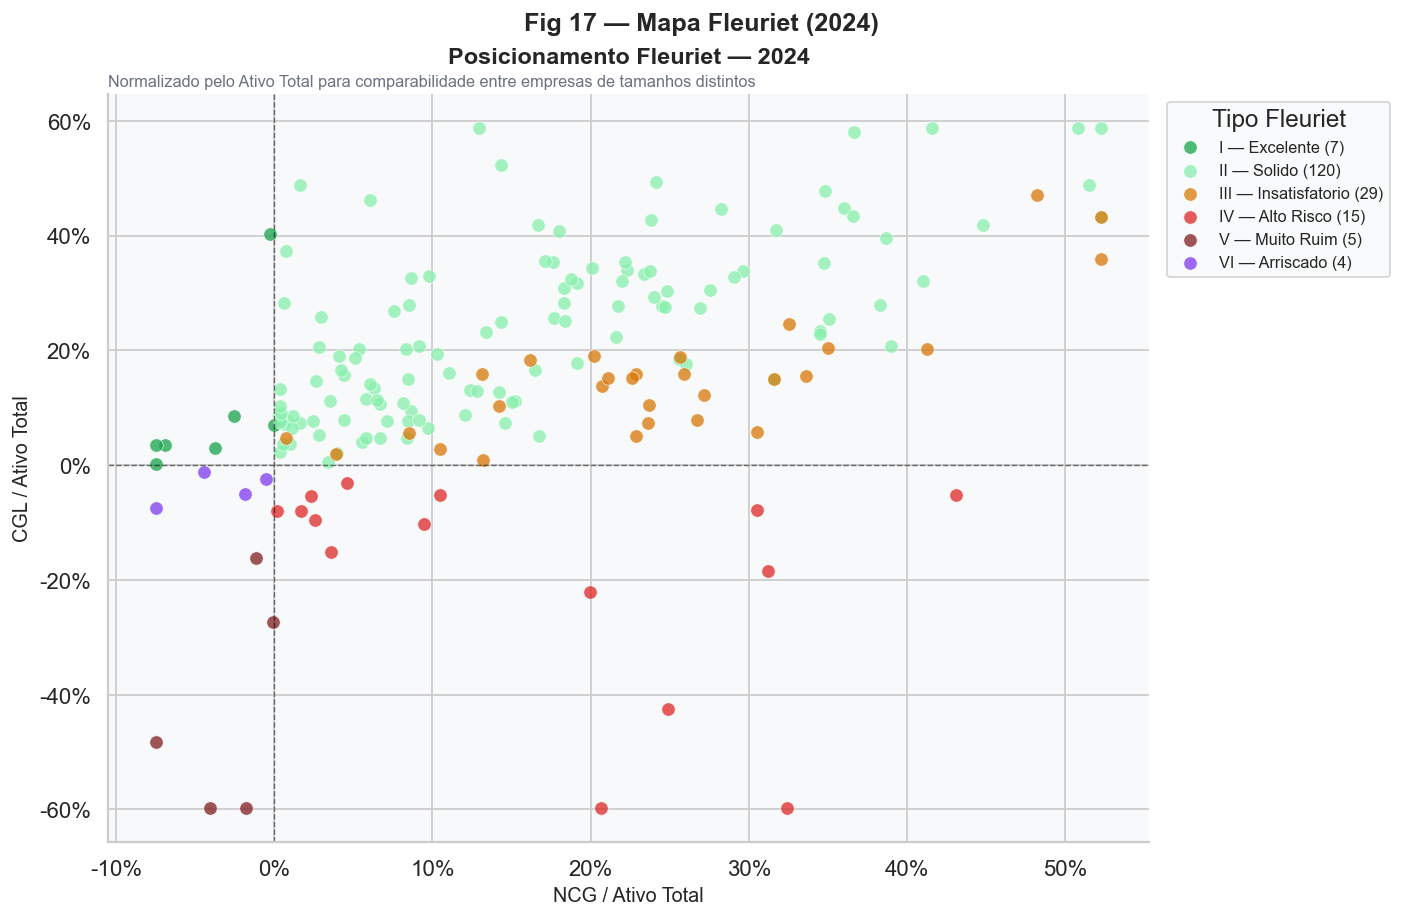

In [20]:
# ── 7b. Scatter CGL × NCG (último ano) — colorido por Tipo Fleuriet ──────────
df_fl_last = df[df['ANO'] == ano_max].copy()
df_fl_last['CGL_VIZ'] = clip_viz(df_fl_last['IND_CGL'] / df_fl_last['V01_ATIVO_TOTAL'])
df_fl_last['NCG_VIZ'] = clip_viz(df_fl_last['IND_NCG'] / df_fl_last['V01_ATIVO_TOTAL'])
df_fl_plot = df_fl_last[df_fl_last['FLEURIET'] != 'Indefinido'].dropna(subset=['CGL_VIZ','NCG_VIZ'])

PALETTE_FL = {k: c for k, c in zip(ORDER_FL, COLOR_FL) if k != 'Indefinido'}

fig, ax = plt.subplots(figsize=(11, 7))
for tipo, cor in PALETTE_FL.items():
    sub = df_fl_plot[df_fl_plot['FLEURIET'] == tipo]
    if len(sub) == 0:
        continue
    ax.scatter(sub['NCG_VIZ'], sub['CGL_VIZ'], label=f'{tipo} ({len(sub)})',
               color=cor, alpha=0.75, s=55, edgecolors='white', linewidth=0.4)

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('NCG / Ativo Total')
ax.set_ylabel('CGL / Ativo Total')
ax.set_title(f'Posicionamento Fleuriet — {ano_max}')
add_subtitle(ax, 'Normalizado pelo Ativo Total para comparabilidade entre empresas de tamanhos distintos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax.legend(title='Tipo Fleuriet', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.suptitle(f'Fig 17 — Mapa Fleuriet ({ano_max})', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 8 · Tabela de Benchmarking Setorial

> Estatísticas descritivas (P25 · P50 · P75 · P90) por setor para os principais indicadores.
> Referência consultiva para posicionar uma empresa individualmente em seu setor.


In [21]:
# ── 8a. Tabela de percentis por setor ────────────────────────────────────────
BENCH_COLS = {
    'IND_LIQUIDEZ_CORRENTE': 'Liq. Corrente',
    'IND_PCT_AT':            'PCT/AT (%)',
    'IND_MARGEM_BRUTA':      'Margem Bruta (%)',
    'IND_MARGEM_LIQUIDA':    'Margem Líquida (%)',
    'IND_ROE':               'ROE (%)',
    'IND_ROA':               'ROA (%)',
    'IND_CICLO_FINANCEIRO':  'Ciclo Fin. (dias)',
}

pct_frames = []
for col, label in BENCH_COLS.items():
    grp = df_top.groupby('SETOR_LABEL')[col].describe(percentiles=[.25,.50,.75,.90])
    grp = grp[['25%','50%','75%','90%']].rename(columns={'25%':'P25','50%':'P50','75%':'P75','90%':'P90'})
    grp.columns = pd.MultiIndex.from_tuples([(label, c) for c in grp.columns])
    pct_frames.append(grp)

bench_table = pd.concat(pct_frames, axis=1)

# Formatar %
pct_ind = ['PCT/AT (%)', 'Margem Bruta (%)', 'Margem Líquida (%)', 'ROE (%)', 'ROA (%)']
for col_l in pct_ind:
    if col_l in bench_table.columns.get_level_values(0):
        bench_table[col_l] = bench_table[col_l].applymap(lambda x: f'{x*100:.1f}%' if pd.notna(x) else '—')
for col_l in ['Liq. Corrente']:
    if col_l in bench_table.columns.get_level_values(0):
        bench_table[col_l] = bench_table[col_l].applymap(lambda x: f'{x:.2f}' if pd.notna(x) else '—')
for col_l in ['Ciclo Fin. (dias)']:
    if col_l in bench_table.columns.get_level_values(0):
        bench_table[col_l] = bench_table[col_l].applymap(lambda x: f'{x:.0f}d' if pd.notna(x) else '—')

display(bench_table.style
        .set_caption('Benchmarking Setorial — Percentis Históricos (2010–2024)')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold')]},
            {'selector': 'th', 'props': [('background-color','#1E40AF'),('color','white'),('font-size','10px')]},
            {'selector': 'td', 'props': [('font-size','10px'),('text-align','center')]},
        ])
)


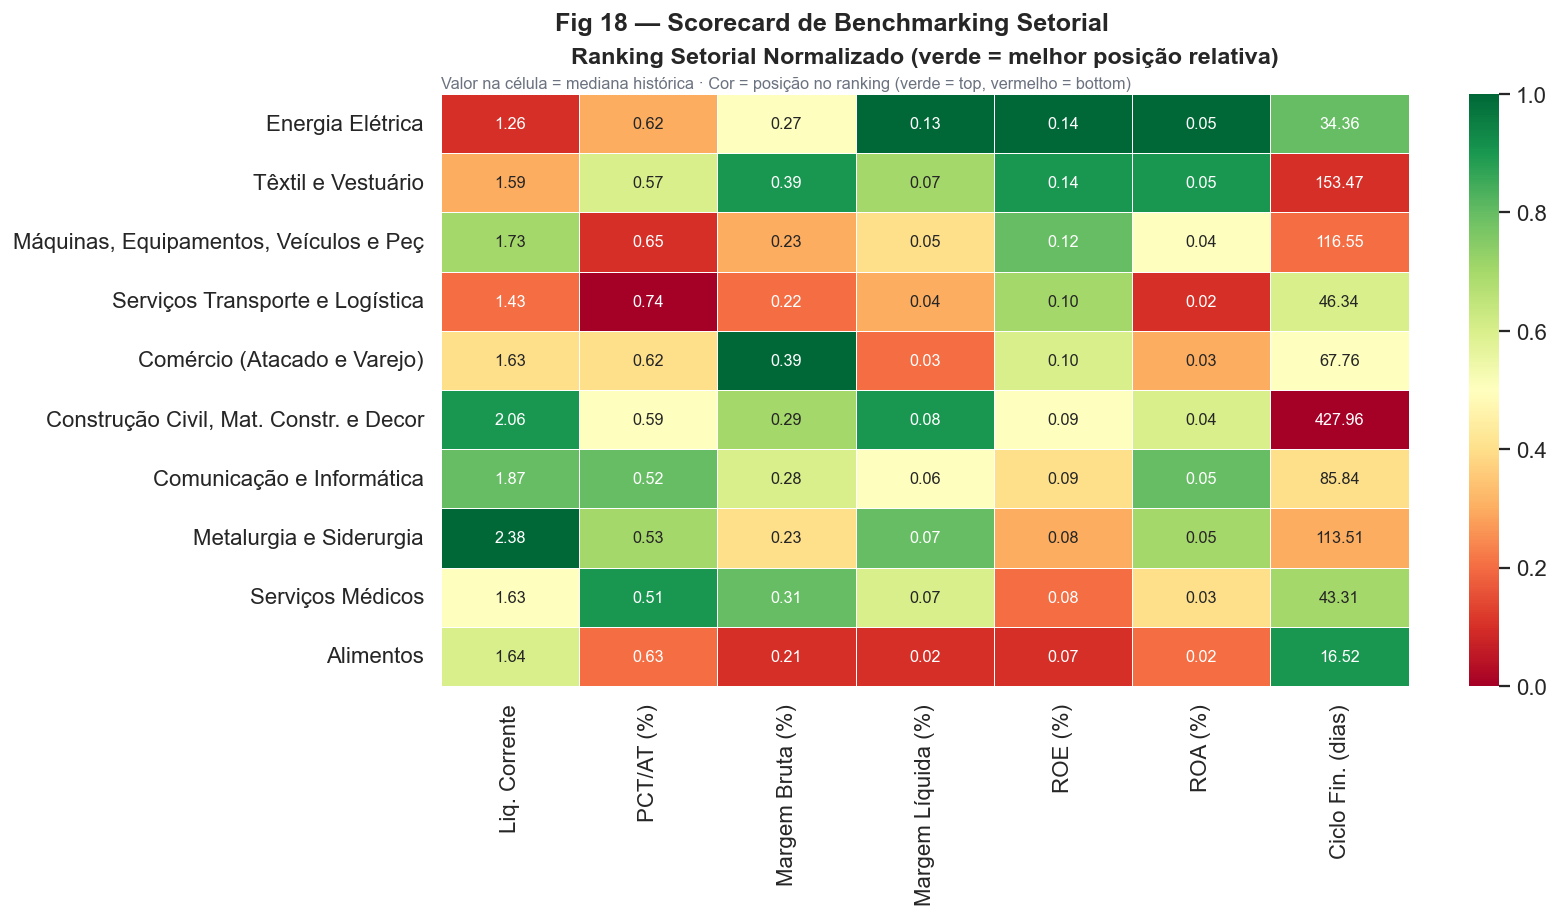

In [22]:
# ── 8b. Heatmap de ranking setorial (medianas normalizadas) ──────────────────
bench_med = df_top.groupby('SETOR_LABEL')[list(BENCH_COLS.keys())].median()
bench_med.columns = list(BENCH_COLS.values())

# Normalizar 0-1 por coluna (rank percentual)
bench_rank = bench_med.rank(pct=True)
# Inverter colunas onde menor = melhor
invert_cols = ['PCT/AT (%)', 'Ciclo Fin. (dias)']
for c in invert_cols:
    if c in bench_rank.columns:
        bench_rank[c] = 1 - bench_rank[c]

bench_rank = bench_rank.sort_values('ROE (%)', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    bench_rank, annot=bench_med.loc[bench_rank.index].applymap(
        lambda x: f'{x:.2f}' if isinstance(x, float) else x
    ),
    fmt='', cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Ranking Setorial Normalizado (verde = melhor posição relativa)')
add_subtitle(ax, 'Valor na célula = mediana histórica · Cor = posição no ranking (verde = top, vermelho = bottom)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.suptitle('Fig 18 — Scorecard de Benchmarking Setorial', y=1.01, fontsize=14, fontweight='bold')
plt.show()


---
## 9 · Radar de Alertas — Último Período

> Critérios de alerta aplicados ao último ano disponível de cada empresa.
> Útil para triagem rápida antes de análise fundamentalista individual.


In [23]:
# ── 9a. Tabela de alertas ────────────────────────────────────────────────────
df_alert = (
    df.sort_values('ANO', ascending=False)
      .groupby('CNPJ_CIA')
      .first()
      .reset_index()
)

alertas = []
criterios = [
    ('LC_CRITICA',   df_alert['IND_LIQUIDEZ_CORRENTE'] < 1.0,  'Liq. Corrente < 1,0 (risco de insolvência CP)'),
    ('PCAT_ALTO',    df_alert['IND_PCT_AT'] > 0.75,             'PCT/AT > 75% (muito dependente de dívida)'),
    ('ML_NEGATIVA',  df_alert['IND_MARGEM_LIQUIDA'] < -0.05,    'Margem Líquida < −5% (prejuízo operacional)'),
    ('ROE_NEGATIVO', df_alert['IND_ROE'] < 0,                   'ROE < 0 (destruindo valor para o acionista)'),
    ('CICLO_LONGO',  df_alert['IND_CICLO_FINANCEIRO'] > 365,    'Ciclo Financeiro > 365 dias'),
    ('FLEURIET_IV_V', df_alert['FLEURIET'].isin(['IV — Alto Risco','V — Muito Ruim']), 'Fleuriet Tipo IV ou V'),
]

df_alert_flags = df_alert[['CNPJ_CIA','RAZAO_SOCIAL','SETOR_LABEL','ANO']].copy()
for flag, mask, _ in criterios:
    df_alert_flags[flag] = mask.values

df_alert_flags['N_ALERTAS'] = df_alert_flags[[f for f,_,_ in criterios]].sum(axis=1)
df_alert_flags = df_alert_flags.sort_values('N_ALERTAS', ascending=False)
multi_alerta = df_alert_flags[df_alert_flags['N_ALERTAS'] >= 3]

print(f'⚠️  Empresas com ≥ 3 alertas simultâneos: {len(multi_alerta)}')

# Estatística por critério
print('\n📊 FREQUÊNCIA POR CRITÉRIO (último período de cada empresa):')
print('─' * 60)
total_emp = len(df_alert_flags)
for flag, _, desc in criterios:
    n = df_alert_flags[flag].sum()
    print(f'  {flag:<15} {n:>4} / {total_emp}  ({n/total_emp*100:.1f}%)  — {desc}')


⚠️  Empresas com ≥ 3 alertas simultâneos: 28

📊 FREQUÊNCIA POR CRITÉRIO (último período de cada empresa):
────────────────────────────────────────────────────────────
  LC_CRITICA        36 / 202  (17.8%)  — Liq. Corrente < 1,0 (risco de insolvência CP)
  PCAT_ALTO         55 / 202  (27.2%)  — PCT/AT > 75% (muito dependente de dívida)
  ML_NEGATIVA       30 / 202  (14.9%)  — Margem Líquida < −5% (prejuízo operacional)
  ROE_NEGATIVO      40 / 202  (19.8%)  — ROE < 0 (destruindo valor para o acionista)
  CICLO_LONGO       13 / 202  (6.4%)  — Ciclo Financeiro > 365 dias
  FLEURIET_IV_V     21 / 202  (10.4%)  — Fleuriet Tipo IV ou V


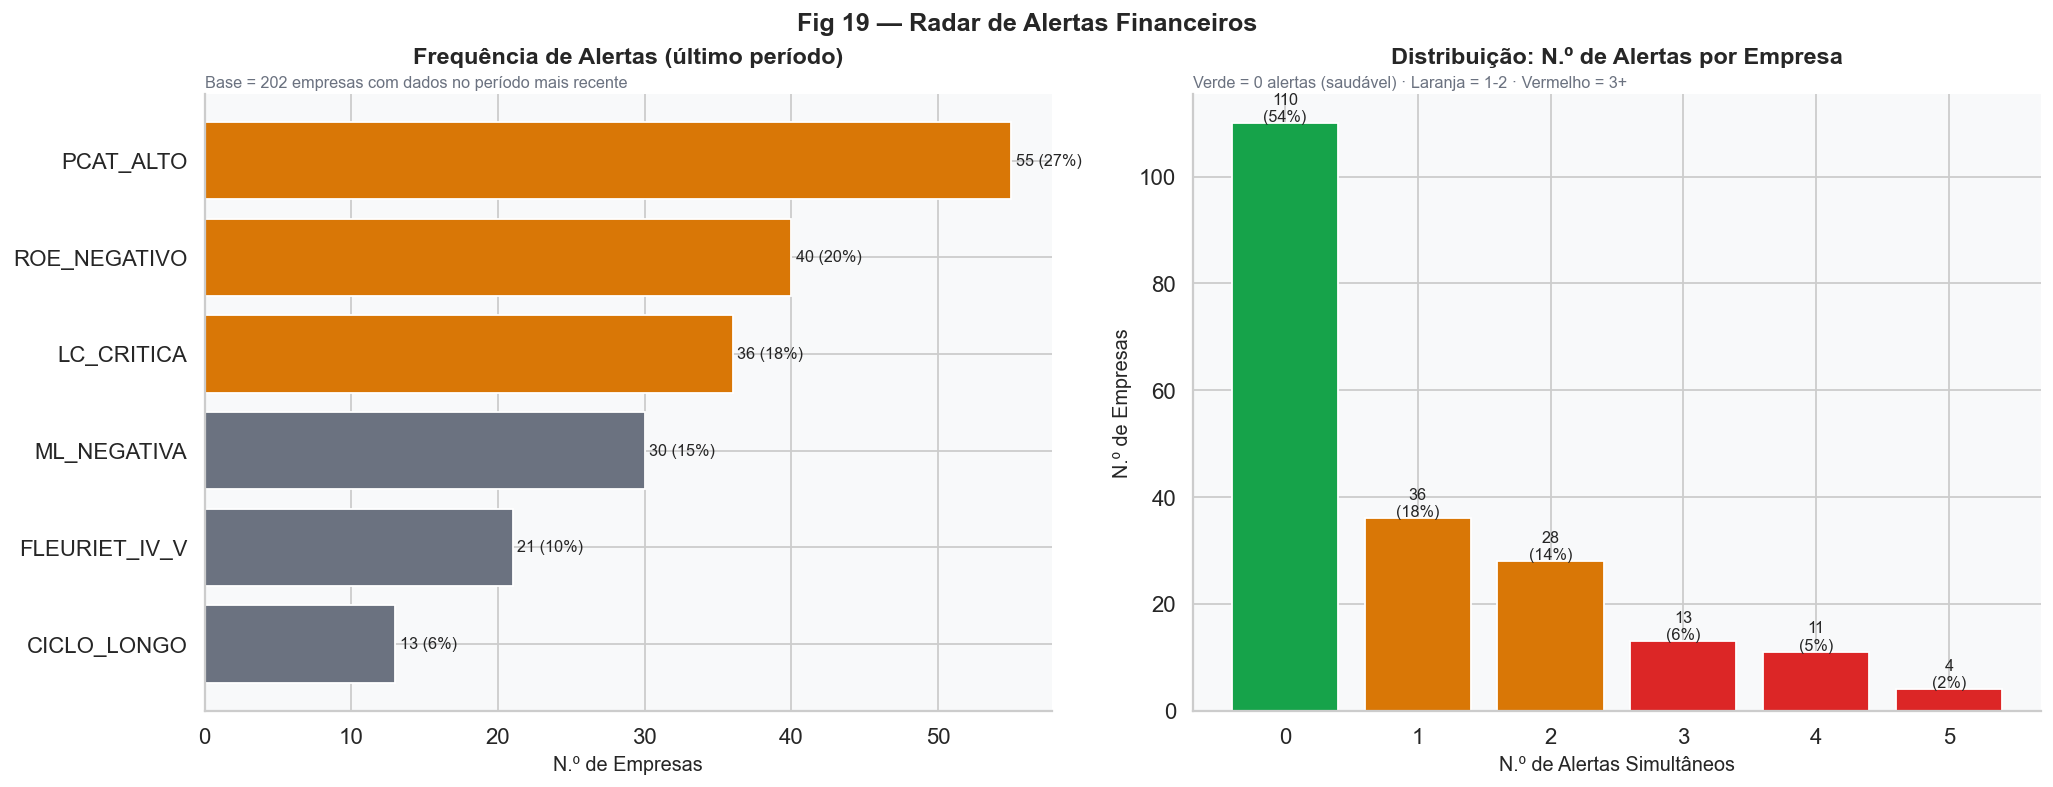

In [24]:
# ── 9b. Visualização de alertas ──────────────────────────────────────────────
flag_names = [f for f,_,_ in criterios]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequência de cada alerta
freq = df_alert_flags[flag_names].sum().sort_values(ascending=True)
colors_alert = [C_RED if v > total_emp * 0.3 else C_ORANGE if v > total_emp * 0.15 else C_GRAY
                for v in freq]
bars = axes[0].barh(freq.index, freq.values, color=colors_alert)
for bar, val in zip(bars, freq.values):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/total_emp*100:.0f}%)', va='center', fontsize=9)
axes[0].set_title('Frequência de Alertas (último período)')
add_subtitle(axes[0], f'Base = {total_emp} empresas com dados no período mais recente')
axes[0].set_xlabel('N.º de Empresas')

# Distribuição N.º de alertas por empresa
alert_dist = df_alert_flags['N_ALERTAS'].value_counts().sort_index()
colors_n = [C_GREEN if k == 0 else (C_ORANGE if k <= 2 else C_RED) for k in alert_dist.index]
axes[1].bar(alert_dist.index.astype(str), alert_dist.values, color=colors_n)
for i, (k, v) in enumerate(alert_dist.items()):
    axes[1].text(i, v + 0.3, f'{v}\n({v/total_emp*100:.0f}%)', ha='center', fontsize=9)
axes[1].set_title('Distribuição: N.º de Alertas por Empresa')
add_subtitle(axes[1], 'Verde = 0 alertas (saudável) · Laranja = 1-2 · Vermelho = 3+')
axes[1].set_xlabel('N.º de Alertas Simultâneos')
axes[1].set_ylabel('N.º de Empresas')

plt.tight_layout()
plt.suptitle('Fig 19 — Radar de Alertas Financeiros', y=1.01, fontsize=14, fontweight='bold')
plt.show()


In [25]:
# ── 9c. Top 15 empresas com mais alertas ─────────────────────────────────────
top_alert = multi_alerta.head(15)[
    ['RAZAO_SOCIAL','SETOR_LABEL','ANO','N_ALERTAS'] + flag_names
].copy()

def highlight_flags(val):
    if val is True:  return 'background-color: #FEE2E2; color: #991B1B; font-weight: bold'
    if val is False: return 'background-color: #F0FDF4; color: #166534'
    return ''

print(f'\n🚨 Top empresas com mais alertas simultâneos (≥ 3):')
display(
    top_alert.style
    .applymap(highlight_flags, subset=flag_names)
    .set_caption('🚨 Empresas com múltiplos alertas — requer análise individual aprofundada')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','12px'),('font-weight','bold'),('color','#991B1B')]},
        {'selector': 'th',      'props': [('background-color','#1F2937'),('color','white'),('font-size','10px')]},
        {'selector': 'td',      'props': [('font-size','10px')]},
    ])
)



🚨 Top empresas com mais alertas simultâneos (≥ 3):


,RAZAO_SOCIAL,SETOR_LABEL,ANO,N_ALERTAS,LC_CRITICA,PCAT_ALTO,ML_NEGATIVA,ROE_NEGATIVO,CICLO_LONGO,FLEURIET_IV_V
66,AERIS IND. E COM. DE EQUIP. PARA GER. DE ENG. S.A.,"Máquinas, Equipamentos, Veículos e Peç",2024,5,True,True,True,True,False,True
68,HIDROVIAS DO BRASIL S.A.,Serviços Transporte e Logística,2024,5,True,True,True,True,False,True
153,MARISA LOJAS SA,Comércio (Atacado e Varejo),2024,5,True,True,True,True,False,True
155,AZEVEDO & TRAVASSOS SA,"Construção Civil, Mat. Constr. e Decor",2024,5,True,True,True,True,False,True
57,INC EMPREENDIMENTOS IMOBILIÁRIOS S.A.,"Construção Civil, Mat. Constr. e Decor",2024,4,True,True,False,False,True,True
59,CVC BRASIL OPERADORA E AGÊNCIA DE VIAGENS SA,Hospedagem e Turismo,2024,4,True,True,True,True,False,False
92,FERTILIZANTES HERINGER S.A.,Petroquímicos e Borracha,2012,4,True,True,False,True,False,True
105,GRUPO CASAS BAHIA S.A.,Comércio (Atacado e Varejo),2024,4,True,True,False,True,False,True
4,BBM LOGÍSTICA S.A.,Serviços Transporte e Logística,2024,4,True,True,True,False,False,True
141,"ALLPARK EMPREENDIMENTOS, PARTICIPAÇÕES E SERVIÇOS S.A.",Serviços Transporte e Logística,2024,4,True,True,False,True,False,True


---
## 10 · Sumário Executivo

In [26]:
# ── Sumário com métricas-chave do universo (último período) ──────────────────
metrics = {
    'Liquidez Corrente (mediana)':  df_last['IND_LIQUIDEZ_CORRENTE'].median(),
    'Margem Líquida (mediana)':     df_last['IND_MARGEM_LIQUIDA'].median(),
    'Margem Operacional (mediana)': df_last['IND_MARGEM_OPERACIONAL'].median(),
    'ROE (mediana)':                df_last['IND_ROE'].median(),
    'ROA (mediana)':                df_last['IND_ROA'].median(),
    'PCT/AT (mediana)':             df_last['IND_PCT_AT'].median(),
    'Ciclo Financeiro (mediana)':   df_last['IND_CICLO_FINANCEIRO'].median(),
    'Fleuriet Tipo II+I (%)':       (df_fl_last['FLEURIET'].isin(['I — Excelente','II — Sólido'])).mean(),
    'Empresas c/ ≥3 alertas (%)':  (df_alert_flags['N_ALERTAS'] >= 3).mean(),
}

print(f'\n{"═"*55}')
print(f'  SUMÁRIO EXECUTIVO — UNIVERSO B3 ({ano_max})')
print(f'  Base: {df_last["CNPJ_CIA"].nunique()} empresas')
print(f'{"═"*55}')
for label, val in metrics.items():
    if '%' in label:
        print(f'  {label:<38}  {val*100:>6.1f}%')
    elif 'dias' in label.lower() or 'ciclo' in label.lower():
        print(f'  {label:<38}  {val:>6.0f} dias')
    elif 'liquidez' in label.lower():
        print(f'  {label:<38}  {val:>6.2f}×')
    else:
        print(f'  {label:<38}  {val*100:>6.1f}%')
print(f'{"═"*55}')
print('\n✅ Análise completa.')



═══════════════════════════════════════════════════════
  SUMÁRIO EXECUTIVO — UNIVERSO B3 (2024)
  Base: 191 empresas
═══════════════════════════════════════════════════════
  Liquidez Corrente (mediana)               1.60×
  Margem Líquida (mediana)                   5.5%
  Margem Operacional (mediana)              12.0%
  ROE (mediana)                              9.6%
  ROA (mediana)                              3.2%
  PCT/AT (mediana)                          65.5%
  Ciclo Financeiro (mediana)                  93 dias
  Fleuriet Tipo II+I (%)                     3.7%
  Empresas c/ ≥3 alertas (%)                13.9%
═══════════════════════════════════════════════════════

✅ Análise completa.
